# Uncertainties in the sub-grid transport of CO2 in IFS


In [1]:
import xarray as xr
import os
import dask
import h5netcdf
import scipy
import pandas as pd
import re
import numpy as np
from datetime import timedelta
import datetime
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import ticker
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker  
import pint
from pint import UnitRegistry
ureg = UnitRegistry()
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'large',
         'axes.labelsize': 22,
         'axes.titlesize':'large',
         'xtick.labelsize':18,
         'ytick.labelsize':18,
         'figure.figsize':[10,7],
         'figure.titlesize':22}
pylab.rcParams.update(params)

import sys
sys.path.append(".")  # Ensures the current directory is in the Python path
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun
from my_classes import DatasetProcessor

In [2]:
dir_in       = "/perm/paaa/IFS"
dir_obs         = "/perm/paaa/observations"
dir_out       = "/perm/paaa/images/CATRINE"


# # name | dir | label
# exp_names = [
#     ('ctrl'     , 'itvc_ctrl_flxntend'       ,  'Control'),
#     # ('TKE'      , 'iupe_TKE_flxntend'        ,  'TKE'),
#     # ('dryMF'    , 'iu8c_dryMF_flxntend'      ,  'dry MF'),
#     # ('reorder'  , 'ius9_reorder_flxntend'    ,  'reorder'),
#     # ('TKEv2'    , 'ivps_TKEv2_flxntend'        ,  'TKEv2'),
#     ('ctrl_9km' , 'ivln_9km_flxntend'   ,  'Control 9 km'),
#     ('ctrl_49r2b','iyw7_ctrl_49r2b'   ,  'Control 49r2b'),
#     ('half_diffusion','j1kz_half_ZCFC_everywhere_49r2b'   ,  'Half diffusion'),
#     ('half_diff_stable','j1m9_half_ZCFC_everywhere_stable_49r2b'   ,  'Half diff stable'),
#     ('half_diff_unstable','j1rv_half_ZCFC_inABL_unstable_49r2b'   ,  'Half diff unstable') 
# ]
# nemo_exp_names = [
#     ('SPP_all',     'iqpa_SPP_noIC'       , 'SPP all'   , 'grey'),
#     ('SPP_conv',    'iqs0_SPP_noIC_conv'  , 'SPP conv'  , 'red'),
#     ('SPP_diff',    'issq_SPP_noIC_turb'  , 'SPP turb'  , 'green'),
#     ('SPP_rad',     'issr_SPP_noIC_rad'   , 'SPP rad'   , 'blue'),
# ]

exp_names = [
    # ('ctrl'                 , 'itvc_ctrl_flxntend'                      , '49r1 tco399'                 ,'#7C1472'),
    # ('ctrl_9km'             , 'ivln_9km_flxntend'                       , '49r1 tco1279 '               ,'#06CA8C'),

    ('ctrl_49r2b'               , 'iyw7_ctrl_49r2b'                         , 'Control'                     ,'#D04848'),  # to reextract
    ('9km_49r2b'                , 'j1rw_9km_49r2b'                          , 'Hres_9km'                     ,"#07AD78"), # to reextract
    # ('dryMF_arctan'             , 'j5tj_dryMF_arctan'                       , 'dryMF'                       ,'#7C1471'), 
    # ('half_diffusion'           , 'j1kz_half_ZCFC_everywhere_49r2b'         , '0.5 diff'                    ,'#6895D2'),
    # ('half_diff_stable'         , 'j1m9_half_ZCFC_everywhere_stable'        , 'Red_diff_stab'            ,'#F3B95F'),
    # ('half_diff_unstable'       , 'j1t7_half_ZCFC_everywhere_notStable'     , 'Red_diff_nonstab'          ,"#72E9F9"), 
    # ('half_diff_unstable_abl'   , 'j1rv_half_ZCFC_inABL_notStable'          , '0.5 diff, unstable,\ninABL ' ,'#59981A'),
    ('short_tail_ABL'           , 'j7fk_short_tail_ABL'                 , 'S_tail' ,'#59981A'),
    ('dryMF_49r2b'             , 'j7y2_dryMF_49r2b'                       , 'dryMF'                       ,'#7C1471'), 

    
]


nemo_exp_names = [
    # ('SPP_all'               , 'j4it_SPP_all'                            , 'SPP all 8'              ,'grey'), 
    # ('SPP_turb'              , 'j6d0_SPP_turb'                           , 'SPP turb 8'             ,'blue'), 
    # ('SPP_rkap'              , 'j6d5_SPP_rkap'                           , 'SPP rkap 8'             ,'green'), 

    ('SPP_all_30'            , 'j7v0_SPP_all_30'                         , 'SPP all'           ,'#D04848'),
    ('SPP_turb_30'           , 'j7v1_SPP_turb_30'                        , 'SPP turb'          ,'#72E9F9'),
    ('SPP_rkap_30'           , 'j7v2_SPP_rkap_30'                        , 'SPP rkap'          ,'#F3B95F')
]

sty = ['-','--',':', '-.']

In [3]:
levels = ['z','srf']
lead_time = 0 # do you want to analayse FC day1 (leasd_time = 0) or FC day2 (leasd_time = 24) ? 

str_time = '2022-05-15T03:00'
end_time = '2022-05-21T02:00'

UTC_to_LT = +2 #hours from UTC

#######################################
# Time limits
t0 = datetime.datetime.strptime(str_time, "%Y-%m-%dT%H:%M")
t1 = datetime.datetime.strptime(end_time, "%Y-%m-%dT%H:%M")

cabauw ={
        "lat": 51.971,
        "lon": 4.927,
        "z": [5, 60, 100, 180]
    }

loobos ={
        "lat": 52.166,
        "lon": 5.744,
        "z": [24]
    }

day_hours   = [8, 19]
night_hours = [8, 20]

_midnights = []
_mn = t0.replace(hour=0, minute=0, second=0, microsecond=0)
while _mn <= t1 + timedelta(hours=26):
    _midnights.append(_mn)
    _mn += timedelta(days=1)

In [4]:
# #####  open input to DALES #####
# dir_in_dales = '/perm/paaa/Les/Cases/Catrine/Martin/'
# ## input 
# input = xr.open_mfdataset(dir_in_dales+'input/les_input_catrine_15_18.nc')
# input['time'] = input['time'] + np.timedelta64(2,'h')

# input['wspd'] = np.sqrt(input['u']**2 + input['v']**2)  # wind speed in m/s
# input['wdir'] = np.arctan2(input['v'], input['u'])

In [5]:

# #####################
# ### DALES profiles ###
# dir_dales       = "/perm/paaa/Les/Cases/Catrine/Arseni"

# files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'profiles' in f and f.endswith('.nc')]
# print('Reading '+str(files))
# dales_prof    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':1000})#.sel(time=slice(str_time,end_time))
# dales_prof['time'] = dales_prof['time'].astype('datetime64[ns]') - np.timedelta64(1,'D') + np.timedelta64(UTC_to_LT,'h')
# dales_prof = dales_prof.sel(time=slice(str_time,end_time))
# ## Interpolate half levels to full levels
# for var in dales_prof.data_vars:
#     if 'zm' in dales_prof[var].coords:
#         # Interpolate the variable along the 'zm' coordinate
#         dales_prof[var] = dales_prof[var].interp(zm=dales_prof.zt)
    
#     ## convert co2 concentration to ppm
#     if 'sv' in var:
#         dales_prof[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_prof[var]/1000000) # ????????
#         dales_prof[var+'_ppm'].attrs['units'] = 'PPM'
#         dales_prof[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'

# # Drop the unnecessary dimensions and coordinates
# dales_prof = dales_prof.drop_dims(["zm"])
# dales_prof = dales_prof.sel(zt=slice(0,7000))
# dales_prof_hr = dales_prof.resample(time='1h',label='left').mean().chunk({'time':-1,'zt':-1})


# #####################
# ### DALES 3d fields ###
# ## domain limit:

# files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'loobos_' in f and '_3d' in f and f.endswith('.nc')]
# print('Reading '+str(files))
# dales_3d    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':24,'zt':4,'xt':-1,'yt':-1})
# # convert UTC to local time (+2 hours)
# dales_3d['time'] = dales_3d['time'].astype('datetime64[ns]') + np.timedelta64(2,'D') + np.timedelta64(UTC_to_LT,'h')
# dales_3d = dales_3d.sel(time=slice(str_time,end_time))

# for var in dales_3d.data_vars:
#     ## convert co2 concentration to ppm
#     if 'sv' in var:
#         dales_3d[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_3d[var]/1000000) # ???????
#         dales_3d[var+'_ppm'].attrs['units'] = 'PPM'
#         dales_3d[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'

# # Select tower location
# dales_cabauw = dales_3d.where((dales_3d['lat']>cabauw['lat']-0.005).compute() & (dales_3d['lat']<cabauw['lat']+0.005).compute() &
#                           (dales_3d['lon']>cabauw['lon']-0.005).compute() & (dales_3d['lon']<cabauw['lon']+0.005).compute(),drop=True)

# dales_3d_loobos = dales_3d.where((dales_3d['lat']>loobos['lat']-0.005).compute() & (dales_3d['lat']<loobos['lat']+0.005).compute() &
#                           (dales_3d['lon']>loobos['lon']-0.005).compute() & (dales_3d['lon']<loobos['lon']+0.005).compute(),drop=True)

# dales_2d    = dales_3d.mean(('xt','yt'))
# dales_2d = dales_2d.chunk({'time':-1,'zt':-1})
# dales_cabauw    = dales_cabauw.mean(('xt','yt'))
# dales_3d_loobos = dales_3d_loobos.mean(('xt','yt'))

In [6]:
##### open new Areseni's DALES #####

# ## import DALES profile at Loobos from 3d for qt
# ## import DALES profiles at Loobos from 3d for ta
# # convert ta to th using presh at cener of domain already in dales_prof. 
# #  
# dales_qt = xr.open_dataset(f"{dir_dales}/ruisdael_domain_dales_3d_16_18_05_2022_100m_qt.nc")
# dales_ta = xr.open_dataset(f"{dir_dales}/ruisdael_domain_dales_3d_16_18_05_2022_100m_ta.nc")

# dales_qt_cabauw = dales_qt.where((dales_qt['lat']>cabauw['lat']-0.005).compute() & (dales_qt['lat']<cabauw['lat']+0.005).compute() &
#                           (dales_qt['lon']>cabauw['lon']-0.005).compute() & (dales_qt['lon']<cabauw['lon']+0.005).compute(),drop=True)
# dales_ta_cabauw = dales_ta.where((dales_ta['lat']>cabauw['lat']-0.005).compute() & (dales_ta['lat']<cabauw['lat']+0.005).compute() &
#                           (dales_ta['lon']>cabauw['lon']-0.005).compute() & (dales_ta['lon']<cabauw['lon']+0.005).compute(),drop=True)

# dales_qt_loobos = dales_qt.where((dales_qt['lat']>loobos['lat']-0.005).compute() & (dales_qt['lat']<loobos['lat']+0.005).compute() &
#                           (dales_qt['lon']>loobos['lon']-0.005).compute() & (dales_qt['lon']<loobos['lon']+0.005).compute(),drop=True)
# dales_ta_loobos = dales_ta.where((dales_ta['lat']>loobos['lat']-0.005).compute() & (dales_ta['lat']<loobos['lat']+0.005).compute() &
#                           (dales_ta['lon']>loobos['lon']-0.005).compute() & (dales_ta['lon']<loobos['lon']+0.005).compute(),drop=True)

# dales_ta_loobos = dales_ta_loobos.mean(('xt','yt'))
# dales_qt_loobos = dales_qt_loobos.mean(('xt','yt'))

# dales_ta_cabauw = dales_ta_cabauw.mean(('xt','yt'))
# dales_qt_cabauw = dales_qt_cabauw.mean(('xt','yt'))

# dales_ta_loobos['th'] = mfun.calc_th(dales_ta_loobos['ta'],dales_prof['presh'])
# dales_ta_cabauw['th'] = mfun.calc_th(dales_ta_cabauw['ta'],dales_prof['presh'])

In [7]:
def interp_pblh(Ri, zt, threshold=0.25):
    # Difference from threshold
    diff = Ri - threshold

    # Condition: Ri > 0.25
    mask = diff > 0

    # Find index along zt where Ri first exceeds threshold
    ri_ind = mask.argmax(dim="zt")

    # Gather values just before and after the threshold crossing
    ri_low = Ri.isel(zt=ri_ind - 1)
    ri_high = Ri.isel(zt=ri_ind)

    zt_low = zt.isel(zt=ri_ind - 1)
    zt_high = zt.isel(zt=ri_ind)

    # Linear interpolation to where Ri == threshold
    pblh = zt_low + (zt_high - zt_low) * ((threshold - ri_low) / (ri_high - ri_low))

    return pblh

In [8]:
# #### Not accurate! you need the surface values! this lowest level is about 12 m ####
# thv_surf = dales_prof_hr['thv'].sel(zt=0,method='nearest') +2.5 ####?????????????
# z_surf  = dales_prof_hr['zt'].sel(zt=0,method='nearest') -10
# u_surf  = dales_prof_hr['u'].sel(zt=0,method='nearest') *0.2
# v_surf  = dales_prof_hr['v'].sel(zt=0,method='nearest') *0.2
# ####################

# num = mfun.g/(thv_surf) * (dales_prof_hr['thv'] - (thv_surf)) * (dales_prof_hr['zt']-(z_surf))
# den = (dales_prof_hr['u'] - (u_surf))**2 + (dales_prof_hr['v'] - (v_surf))**2

# # num = mfun.g/dales_prof_hr['thv'] * (dales_prof_hr['thv'].diff('zt')) * (dales_prof_hr['zt'].diff('zt'))
# # den = (dales_prof_hr['u'].diff('zt'))**2 + (dales_prof_hr['v'].diff('zt'))**2

# Ri  = num/den 

# pblh = interp_pblh(Ri.compute(),dales_prof_hr['zt'],0.25)

# pblh['time'] = pblh['time'].astype('datetime64[ns]') + np.timedelta64(3,'h')

In [9]:
#####  open IFS forecasts #####
subdomains = ["netherlands","HPB_tower"]
# subdomains = ["netherlands_2","HPB_tower"]


# map dataset categories to filename suffix
categories_nl = {
    "3d_nl":        "_processed.nc",   # 3D + surface full datasets
    "slab_nl":    "_slab.nc",
    "cabauw":  "_cabauw.nc",
    "loobos":  "_loobos.nc",
}
categories_hpb = {
    "3d_hpb":        "_processed.nc",   # 3D + surface full datasets
    "slab_hpb":    "_slab.nc",
    "HPB_tower":  "_HPB_tower.nc",
}

categories = {}
if 'netherlands' in subdomains: # "netherlands_2"
    categories |= categories_nl
if 'HPB_tower' in subdomains:
    categories |= categories_hpb
# initialise dictionaries
IFS = {cat: {"z": {}, "srf": {}} for cat in categories}

for exp, exp_longname, _,_ in exp_names:
    for cat, suffix in categories.items():
        if cat in categories_nl:
            subdomain = "netherlands" # "netherlands_2"
        elif cat in categories_hpb:
            subdomain = "HPB_tower"
            if exp_longname not in ["iyw7_ctrl_49r2b","j7y2_dryMF_49r2b","j7fk_short_tail_ABL","j1rw_9km_49r2b"]:
                continue
        tag = f"t{lead_time}{suffix}"
        for level in ["z", "srf"]:
            files = [
                os.path.join(dir_in,subdomain ,"fc", f)
                for f in os.listdir(os.path.join(dir_in,subdomain, "fc"))
                if exp_longname + f"_{level}" in f and f.endswith(tag)
            ]
            print(f"Reading {cat or 'processed'} {level} files:")
            print(files)
            IFS[cat][level][exp] = xr.open_mfdataset(files, combine="by_coords")
            IFS[cat][level][exp] = IFS[cat][level][exp].sel(time=slice(t0, t1))
            # remove time duplicates (required for .sel(..., method="nearest"))
            if "time" in IFS[cat][level][exp].dims:
                IFS[cat][level][exp] = IFS[cat][level][exp].sortby("time")
                _t_index = IFS[cat][level][exp].indexes.get("time")
                if _t_index is not None and not _t_index.is_unique:
                    IFS[cat][level][exp] = IFS[cat][level][exp].isel(time=~_t_index.duplicated())
            if level == 'z':
                IFS[cat][level][exp]['th'] = mfun.calc_th(IFS[cat][level][exp]['t'],IFS[cat][level][exp]['p'])
                IFS[cat][level][exp]['thl'] = mfun.calc_thl(IFS[cat][level][exp]['th'],IFS[cat][level][exp]['clwc'],IFS[cat][level][exp]['p'])
            

            # IFS[cat][level][exp].load()      # read data into memory
            # IFS[cat][level][exp].close()
            

Reading 3d_nl z files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_z_t0_processed.nc']
Reading 3d_nl srf files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_srf_t0_processed.nc']
Reading slab_nl z files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_z_t0_slab.nc']
Reading slab_nl srf files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_srf_t0_slab.nc']
Reading cabauw z files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_z_t0_cabauw.nc']
Reading cabauw srf files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_srf_t0_cabauw.nc']
Reading loobos z files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_z_t0_loobos.nc']
Reading loobos srf files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_srf_t0_loobos.nc']
Reading 3d_hpb z files:
['/perm/paaa/IFS/HPB_tower/fc/iyw7_ctrl_49r2b_z_t0_processed.nc']
Reading 3d_hpb srf files:
['/perm/paaa/IFS/HPB_tower/fc/iyw7_ctrl_49r2b_srf_t0_processed.nc']
Reading slab_hpb z files:
['/perm/paaa/IFS/HPB_tower/fc/iyw7_ctrl_49r2b_z_t0_slab.nc']

In [10]:
## If you still need to deaccumulate or process something....

# ds_z_slab['uflx_conv'] = mfun.deacc_variable(ds_z_slab['uflx_conv'],restart=1)
# ds_z_slab['uflx_diff'] = mfun.deacc_variable(ds_z_slab['uflx_diff'],restart=1)
# ds_z_slab['uflx_dyn'] = mfun.deacc_variable(ds_z_slab['uflx_dyn'],restart=1)



for cat, suffix in categories.items():
    t = {}
    for exp in IFS[cat]['z'].keys():
        # rename temperature 
        if 't' in IFS[cat]['z'][exp].data_vars:
            IFS[cat]['z'][exp] = IFS[cat]['z'][exp].rename({'t':'T'})
        # for var in ['u','v','T','q','co2','ch4']:
        for var in ['u','v','T','q','co2']:
            IFS[cat]['z'][exp][f'd{var}dt_tot'].attrs = IFS['slab_nl']['z'][exp][f'd{var}dt_dyn'].attrs.copy()
        
        # if co2_flx_dyn is avaiable rename it as co2flx_dyn
        try:
            ds = IFS[cat]['z'][exp]
            if 'co2_flx_dyn' in ds.data_vars:
                ds = ds.rename({'co2_flx_dyn': 'co2flx_dyn'})
                IFS[cat]['z'][exp] = ds
        except KeyError:
            print(f"co2flx_dyn {exp} already named.")

        # for var in IFS[cat]['z'][exp].data_vars:
        #     if 'co2flx' in var:
        #         old_units = IFS['slab']['z'][exp][var].attrs['units']
        #         print(exp,cat, var, old_units)
                # IFS[cat]['z'][exp][var] = mfun.concentration_to_ppm('co2', IFS[cat]['z'][exp][var] / 1000)
                # IFS[cat]['z'][exp][var].attrs['units'] = old_units.replace('g', 'PPM')


        # check if all experiments have the same times
        if exp not in ["9km_49r2b", "half_diff_stable", "half_diff_unstable"]:
            t[exp] = set(IFS[cat]['z'][exp].time.values)

    common_times = sorted(set.intersection(*t.values()))
    print(f"Common times for {cat}: {len(common_times)}")
    print(f"Control times for {cat}: {len(t['ctrl_49r2b'])}")
    # if cat in ["3d_hpb","slab_hpb","HPB_tower"]:
    #     for exp in IFS[cat]['z']:
    #         IFS[cat]['z'][exp] = IFS[cat]['z'][exp].sel(time=common_times)

Common times for 3d_nl: 144
Control times for 3d_nl: 144
Common times for slab_nl: 144
Control times for slab_nl: 144
Common times for cabauw: 144
Control times for cabauw: 144
Common times for loobos: 144
Control times for loobos: 144
Common times for 3d_hpb: 144
Control times for 3d_hpb: 144
Common times for slab_hpb: 144
Control times for slab_hpb: 144
Common times for HPB_tower: 144
Control times for HPB_tower: 144


In [11]:
## compute tendency as difference between final and intial co2 profiles
for var in ['u','v','T','q','co2','ch4']:
    for cat in ['slab_nl','slab_hpb']:
        for exp in IFS[cat]['z'].keys():
         IFS[cat]['z'][exp][f'd{var}dt_diff_check'] = (IFS[cat]['z'][exp][var].diff('time') / 1)#hr   # in ppm/hour

In [ ]:
#####  open IFS nemo experiments #####
IFS_nemo = {cat: {"z": {}, "srf": {}} for cat in categories}

for exp, exp_longname, _, _ in nemo_exp_names:
    for cat, suffix in categories.items():
        if cat in categories_nl:
            subdomain = "netherlands" # "netherlands_2"
        elif cat in categories_hpb:
            subdomain = "HPB_tower"
            if exp_longname not in ["j7v0_SPP_all_30","j7v2_SPP_rkap_30"]:
                continue
        tag = f"t{lead_time}{suffix}"
        for level in ["z", "srf"]:
            files = [
                os.path.join(dir_in,subdomain, "pf", f)
                for f in os.listdir(os.path.join(dir_in,subdomain, "pf"))
                if exp_longname + f"_{level}" in f and f.endswith(tag)
            ]
            print(f"Reading {cat or 'processed'} {level} files:")
            print(files)
            IFS_nemo[cat][level][exp] = xr.open_mfdataset(files, combine="by_coords")
            IFS_nemo[cat][level][exp] = IFS_nemo[cat][level][exp].sel(time=slice(t0, t1))
            # remove time duplicates (required for .sel(..., method="nearest"))
            if "time" in IFS_nemo[cat][level][exp].dims:
                IFS_nemo[cat][level][exp] = IFS_nemo[cat][level][exp].sortby("time")
                _t_index = IFS_nemo[cat][level][exp].indexes.get("time")
                if _t_index is not None and not _t_index.is_unique:
                    IFS_nemo[cat][level][exp] = IFS_nemo[cat][level][exp].isel(time=~_t_index.duplicated())
            if level =='z':    
                IFS_nemo[cat][level][exp]['co2_ppm'] = mfun.concentration_to_ppm('co2',IFS_nemo[cat][level][exp]['co2'])
                # IFS_nemo[cat][level][exp]['th'] = mfun.calc_th(IFS_nemo[cat][level][exp]['t'],IFS_nemo[cat][level][exp]['p'])



Reading 3d_nl z files:
['/perm/paaa/IFS/netherlands/pf/j7v0_SPP_all_30_z_t0_processed.nc']
Reading 3d_nl srf files:
['/perm/paaa/IFS/netherlands/pf/j7v0_SPP_all_30_srf_t0_processed.nc']
Reading slab_nl z files:
['/perm/paaa/IFS/netherlands/pf/j7v0_SPP_all_30_z_t0_slab.nc']
Reading slab_nl srf files:
['/perm/paaa/IFS/netherlands/pf/j7v0_SPP_all_30_srf_t0_slab.nc']
Reading cabauw z files:
['/perm/paaa/IFS/netherlands/pf/j7v0_SPP_all_30_z_t0_cabauw.nc']
Reading cabauw srf files:
['/perm/paaa/IFS/netherlands/pf/j7v0_SPP_all_30_srf_t0_cabauw.nc']
Reading loobos z files:
['/perm/paaa/IFS/netherlands/pf/j7v0_SPP_all_30_z_t0_loobos.nc']
Reading loobos srf files:
['/perm/paaa/IFS/netherlands/pf/j7v0_SPP_all_30_srf_t0_loobos.nc']
Reading 3d_hpb z files:
['/perm/paaa/IFS/HPB_tower/pf/j7v0_SPP_all_30_z_t0_processed.nc']
Reading 3d_hpb srf files:
['/perm/paaa/IFS/HPB_tower/pf/j7v0_SPP_all_30_srf_t0_processed.nc']
Reading slab_hpb z files:
['/perm/paaa/IFS/HPB_tower/pf/j7v0_SPP_all_30_z_t0_slab.nc']

In [ ]:
################
#####  OPEN OBSERVATIONS #####
################

#### CABAUW ####
################
ds_cabauw = {}

cabauw_heights = np.array([27, 67, 127, 207])
cabauw_heights_da = xr.DataArray(cabauw_heights, dims=["cabauw_height"])

print('-- Cabauw datasets --')

# 1) #######################
####  obs_surf_flx  ####
########################
# Surface
print ('Dataset name: obs_surf_flx')
obs_name = "cesar_surface_flux"
datestamp = "2022"
files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_surf_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
obs_surf_flx['time'] = obs_surf_flx['time'].astype('datetime64[ns]') + np.timedelta64(UTC_to_LT,'h')
ds_cabauw['obs_surf_flx'] = obs_surf_flx.resample(time='1h',label='right').mean()  ## Label right or left??????
################################################

# 2) ########################
####  obs_tower_flx  ####
#########################
# Tower
print ('Dataset name: obs_tower_flx')
obs_name = "cesar_tower_flux"
datestamp = "2022"
files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_tower_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
# obs_tower_flx['time'] = obs_tower_flx['time'].astype('datetime64[ns]') + np.timedelta64(UTC_to_LT,'h')
# obs_tower_flx = obs_tower_flx.resample(time='1h',label='right').mean()  ## Label right or left??????
ds_cabauw['obs_tower_flx'] = obs_tower_flx.rolling(time=6, center=True).mean()
################################################


# 3) ############################
####  Cabauw_CO2_May2022 ####
#############################
### import CO2 concentration ## 
file = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if 'CO2' in f and f.endswith('.csv')][0]
print ('Dataset name: '+file[30:-4])
# Read the first two rows separately
headers =  pd.read_csv(file, nrows=1).columns.tolist()

# Read the actual data, skipping the units row
df = pd.read_csv(file)
df.columns.values[0] = "time"
df = df.set_index("time")

# # Convert to xarray
ds = df.to_xarray()
for var in ds.variables:
    if var =='time':
        continue
    elif 'flag' in var:
        ds[var].attrs["units"] = ''
    else: 
        ds[var].attrs["units"] = 'PPM'
# # Optional: parse the time if it's not already datetime
ds["time"] = pd.to_datetime(df.index) + np.timedelta64(UTC_to_LT,'h') # to LT (CEST)
# # Now you can assign it to your dict:
ds_cabauw[file[30:-4]] = ds
################################################

# 1) #######################
####  obs_tower_meteo  ####
########################
# Surface
print ('Dataset name: obs_tower_meteo')
obs_name = "cesar_tower_meteo"
datestamp = "2022"
files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_tower_meteo    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
obs_tower_meteo['time'] = obs_tower_meteo['time'].astype('datetime64[ns]') + np.timedelta64(UTC_to_LT,'h')
ds_cabauw['obs_tower_meteo'] = obs_tower_meteo.resample(time='1h',label='right').mean()  ## Label right or left??????
################################################



# 4) #######################
#### BLH StratFinder ####
#
obs_name = "eprofile_L2B_STRATFINDER_cabauw_chm15k-A_v01_2022_15min"
files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and f.endswith('.nc')]
blh_cabauw    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))


-- Cabauw datasets --
Dataset name: obs_surf_flx
Dataset name: obs_tower_flx
Dataset name: Cabauw_CO2_May2022
Dataset name: obs_tower_meteo


In [14]:
# List the levels you want to process
levels = ['27m', '67m', '127m', '207m']

for lvl in levels:
    co2_var = f'co2_{lvl}'
    flag_var = f'co2_flag_{lvl}'
    
    # Mask with NaN where flag is 'N'
    ds_cabauw['Cabauw_CO2_May2022'][co2_var] = ds_cabauw['Cabauw_CO2_May2022'][co2_var].where(
        ds_cabauw['Cabauw_CO2_May2022'][flag_var] != 'N'
    )

# Convert direction to radians
theta = np.deg2rad(ds_cabauw['obs_tower_meteo']['D'])
# Optionally, add to dataset
ds_cabauw['obs_tower_meteo']['u'] = -ds_cabauw['obs_tower_meteo']['F']  * np.sin(theta)  # zonal wind (positive eastward)
ds_cabauw['obs_tower_meteo']['v'] = -ds_cabauw['obs_tower_meteo']['F']  * np.cos(theta)  # meridional wind (positive northward)

In [15]:
## open icos data from ecsmd-compo
ds_towers = xr.open_dataset("/perm/paaa/observations/icos_co2_profiles_co2_20220515_20220520.nc")

In [16]:
# -- Compute CO2 gradient from observations
ds_cabauw['Cabauw_CO2_May2022']['co2_gradient'] = xr.full_like(ds_cabauw['Cabauw_CO2_May2022']['time'], fill_value=np.nan, dtype=np.float64)
for time in ds_cabauw['Cabauw_CO2_May2022']['time']:
    x= np.array([ds_cabauw['Cabauw_CO2_May2022']['co2_27m'].sel(time=time),
                 ds_cabauw['Cabauw_CO2_May2022']['co2_67m'].sel(time=time),
                 ds_cabauw['Cabauw_CO2_May2022']['co2_127m'].sel(time=time),
                 ds_cabauw['Cabauw_CO2_May2022']['co2_207m'].sel(time=time)])
    # Mask NaNs
    mask = ~np.isnan(x) & ~np.isnan(cabauw_heights)
    x_clean = x[mask]
    y_clean = cabauw_heights[mask]

    # Only fit if at least 3 points remain
    if len(x_clean) >= 3:
        ds_cabauw['Cabauw_CO2_May2022']['co2_gradient'].loc[time] = np.polyfit(x_clean, y_clean, 1)[0]
    else:
        ds_cabauw['Cabauw_CO2_May2022']['co2_gradient'].loc[time] = np.nan

In [17]:
# Vars you should consider using:
# Friction velocity (ds_cabauw['obs_tower_flx']['USA005])
# CO2 flux (ds_cabauw['obs_tower_flx']['WC005'])
# Specific humidity flux (ds_cabauw['obs_tower_flx']['WQ005'])
# CO2 density flux (ds_cabauw['obs_tower_flx']['FC005'])

In [18]:
#### LOOBOS ####
################
def csv_to_xarray(path: str) -> xr.Dataset:
    """
    Read a CSV where:
      - Row 1 is header
      - Col 1 ignored
      - Col 2 is date (dimension 'date')
      - Col 3 is height Alt (dimension 'Alt')
      - Col 4 is the data variable (uses its header as the variable name)
    Returns an xarray.Dataset with dims ('date', 'Alt').
    """
    # Read full CSV to keep the real header names
    df = pd.read_csv(path, header=0)

    # Grab the name of the 4th column to preserve the variable's real name
    var_name = df.columns[3]

    # Keep only columns 2,3,4 and normalize names
    df = df.iloc[:, [1, 2, 3]].copy()
    df.columns = ['date', 'Alt', var_name]

    # Parse types
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['Alt'] = pd.to_numeric(df['Alt'], errors='coerce')
    df[var_name] = pd.to_numeric(df[var_name], errors='coerce')

    # Drop rows with missing dimension coords
    df = df.dropna(subset=['date', 'Alt'])
    df = df.drop_duplicates(keep="first")
    # Set index for conversion to xarray
    # df = df.set_index(['date', 'Alt']).sort_index()
    df = df.set_index(['date']).sort_index()


    # Convert to xarray (DataArray) then to Dataset
    # da = df[var_name].to_xarray()
    # ds = da.to_dataset(name=var_name)

    ds = df.to_xarray()
    # ds = da.to_dataset(name=var_name)

    return ds

obs_name = "Loobos_"

files = [os.path.join(dir_obs+'/Loobos', f) for f in os.listdir(dir_obs+'/Loobos') if f.startswith(obs_name) and f.endswith('.csv')]

ds_loobos = {}
print('-- Loobos datasets --')
for file in files:
    print ('Dataset name: '+file[38:-4])
    # print(file)
    if file[38:-4] in ['Aircraft_morn_flux','Aircraft_aft_flux']:
        print('skipping '+file[38:-4]+' for now, need to check the format')
        continue
    # loobos[file[38:-4]] = pd.read_csv(file,skiprows=[1])
    # loobos[file[38:-4]] = loobos[file[38:-4]].to_xarray()

    # First row for headers
    skiprows = 0
    headers = pd.read_csv(file, nrows=0).columns.tolist()
    if file[38:-4] in ['Meteorology','Loobos_Fluxes','Air_Quality','Fluxes']:
        skiprows = 1
        # some files have units in the second row, so we read them separately
        units = pd.read_csv(file, nrows=1).iloc[0].tolist()
    if file[38:-4] in ['Aircraft_co2_mol',]:
        ds = csv_to_xarray(file)
        ds_loobos[file[38:-4]] = ds
        continue

    # Read the actual data, skipping the units row
    df = pd.read_csv(file, skiprows=skiprows)

    # Set correct headers
    df.columns = headers

    # Convert to xarray
    ds = df.to_xarray()

    if skiprows == 1:
        # Assign units as attributes to the DataArray variables
        for var_name, unit in zip(headers[1:], units[1:]):  # skip Timestamp
            if var_name in ds:
                ds[var_name].attrs["units"] = unit
    # Optional: parse the time if it's not already datetime
 
    ds["time"] = pd.to_datetime(df[df.columns[0]])
    
    ds['index'] = ds['time']
    
    ds = ds.drop_vars('time')
    ds = ds.drop_vars('dim_0')
    ds = ds.rename({'index': 'time'})
    ds = ds.set_coords("time")
    # ds = ds.rename({'dim_0': 'index'})
    ds = ds.swap_dims({'dim_0': 'time'})
    # Now you can assign it to your dict:
    ds_loobos[file[38:-4]] = ds

mmgas=44.0095
ds_loobos['Fluxes']['co2_flux'] = ds_loobos['Fluxes']['co2_flux'] * (mmgas/10**3 ) # mmgas=44.0095 g/mol
ds_loobos['Fluxes']['co2_flux'].attrs['units'] = 'mg m-2 s-1'

-- Loobos datasets --
Dataset name: Meteorology
Dataset name: Tower_co2_flux
Dataset name: airsamples_O2_CO2
Dataset name: Aircraft_morn_flux
skipping Aircraft_morn_flux for now, need to check the format
Dataset name: Air_Quality
Dataset name: Fluxes
Dataset name: airsamples_vertical_all
Dataset name: Aircraft_co2_mol
Dataset name: Aircraft_aft_flux
skipping Aircraft_aft_flux for now, need to check the format


In [21]:
ds_loobos['Air_Quality']['co2'] = ds_loobos['Air_Quality']['co2_mixing_ratio'] * (1-ds_loobos['Air_Quality']['h2o_mixing_ratio']/1000)# convert to dry air

In [20]:
### import BLH ## 
file = [os.path.join(dir_obs+'/Loobos', f) for f in os.listdir(dir_obs+'/Loobos') if 'BLH' in f and f.endswith('.csv')][0]
print ('Dataset name: '+file[31:-4])
# Read the first two rows separately
headers = ['time','BLH_radio','BLH_plane']
units   = ['','m','m']

# Read the actual data, skipping the units row
df = pd.read_csv(file)

# # Set correct headers
df.columns = headers
df = df.set_index("time")

# # Convert to xarray
ds = df.to_xarray()

# Assign units as attributes to the DataArray variables
for var_name, unit in zip(headers[1:], units[1:]):  # skip Timestamp
    if var_name in ds:
        ds[var_name].attrs["units"] = unit

# # Optional: parse the time if it's not already datetime
ds["time"] = pd.to_datetime(df.index) + np.timedelta64(1, 'h') # convert to LT (CEST)

# # Now you can assign it to your dict:
ds_loobos[file[31:-4]] = ds

Dataset name: BLH


In [21]:
## define legs within the flights in Aircraft_co2_mol. Each leg is either ascending or descending, and you can use the time limits to select the corresponding data for comparison with the model.
legs = {
    # 17 May
    'leg1' : ('2022-05-17T06:30', '2022-05-17T06:40'),
    'leg2' : ('2022-05-17T06:40', '2022-05-17T07:30'),
    'leg3' : ('2022-05-17T08:00', '2022-05-17T08:50'),
    'leg4' : ('2022-05-17T11:50', '2022-05-17T12:10'),
    'leg5' : ('2022-05-17T12:10', '2022-05-17T12:35'),
    'leg6' : ('2022-05-17T14:00', '2022-05-17T14:20'),
    # 18 May
    'leg7' : ('2022-05-18T06:30', '2022-05-18T06:45'),
    'leg8' : ('2022-05-18T06:45', '2022-05-18T07:05'),
    'leg9' : ('2022-05-18T07:55', '2022-05-18T08:10'),
    'leg10': ('2022-05-18T11:35', '2022-05-18T11:58'),
    'leg11': ('2022-05-18T11:58', '2022-05-18T12:20'),
    'leg12': ('2022-05-18T13:40', '2022-05-18T14:15'),
}

# Precompute mid-times (used for both per-leg and mean profiles)
leg_names = [leg for leg in list(legs.keys()) if leg != 'leg6']

midd_times = {
    leg: pd.to_datetime(legs[leg][0])
    + (pd.to_datetime(legs[leg][1]) - pd.to_datetime(legs[leg][0])) / 2
    for leg in leg_names
}

In [22]:
temp_radio = {}
files = [os.path.join(dir_obs, "Loobos/Radiosondes", f) 
         for f in os.listdir(os.path.join(dir_obs, "Loobos/Radiosondes")) 
         if f.endswith(".csv")]

# define a standard pressure grid
p_grid = np.arange(101700, 47912, -20)
z_grid = np.arange(0, 7000, 5)  # standard height grid in meters

vertical_coordinate = "Height" # or "Pressure", depending on your choice

for file in files:
    # --- extract time from filename ---
    fname = os.path.basename(file).replace(".edited.csv", "")
    # e.g. 2022-05-17_0656_0456UTC
    match = re.match(r"(\d{4}-\d{2}-\d{2})_(\d{4})", fname)
    if match:
        date, hhmm = match.groups()
        file_time = pd.to_datetime(f"{date} {hhmm}", format="%Y-%m-%d %H%M")
    else:
        file_time = pd.NaT  # fallback

    print("Dataset name:", fname, "time:", file_time)

    # --- read the CSV ---
    df = pd.read_csv(file)
    df = df.drop(df.columns[0], axis=1)
    273,15

    if vertical_coordinate == "Pressure":
        ## option 1
        # --- use Pressure as vertical coordinate ---
        df = df.set_index(" Pressure (Pascal)")
        ds = df.to_xarray()
        ds = ds.rename({" Pressure (Pascal)": "Pressure"})  # cleaner name
        ds['Pressure'].attrs["units"] = 'Pa'
        # --- average duplicates along Pressure
        ds_avg = ds.groupby("Pressure").mean(dim="Pressure", skipna=True)
        ds_avg = ds_avg.sortby("Pressure", ascending=False)  # descending for vertical
        # --- interpolate to the standard pressure grid ---
        ds_interp = ds_avg.interp(Pressure=p_grid,kwargs={"fill_value": np.nan})
    elif vertical_coordinate == "Height":
        ## option 2
        # --- use Altitude as vertical coordinate ---
        df = df.set_index("Altitude (m MSL)")
        ds = df.to_xarray()
        ds = ds.rename({"Altitude (m MSL)": "Height"})  # cleaner name
        ds['Height'].attrs["units"] = 'm'
        # --- average duplicates along Pressure
        ds_avg = ds.groupby("Height").mean(dim="Height", skipna=True)
        ds_avg = ds_avg.sortby("Height", ascending=False)  # descending for vertical
        # --- interpolate to the standard pressure grid ---
        ds_interp = ds_avg.interp(Height=z_grid,kwargs={"fill_value": np.nan})

    # --- add time as a new dimension ---
    ds_interp = ds_interp.expand_dims("time").assign_coords(time=[file_time])

    # --- (optional) split variable names and units ---
    for column in df.columns:
        if "(" in column and ")" in column:
            name, unit = column.split("(", 1)
            name, unit = name.strip(), unit.strip(") ")
            ds_interp = ds_interp.rename({column: name})
            ds_interp[name].attrs["units"] = unit

    temp_radio[fname] = ds_interp

loobos_radio = xr.concat(temp_radio.values(), dim="time")
loobos_radio = loobos_radio.sortby("time")

## fix some variables
loobos_radio['T'] = loobos_radio['Temperature'] + 273.15  # convert to Kelvin
loobos_radio['T'].attrs["units"] = 'K'
loobos_radio['u'] = -loobos_radio['u']
loobos_radio['v'] = -loobos_radio['v']

Dataset name: 2022-05-18_0707_0507UTC time: 2022-05-18 07:07:00


/etc/ecmwf/nfs/dh1_home_a/paaa/venv/test_env/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


Dataset name: 2022-05-17_1449_1249UTC time: 2022-05-17 14:49:00
Dataset name: 2022-05-17_0925_0725UTC time: 2022-05-17 09:25:00
Dataset name: 2022-05-17_1825_1625UTC time: 2022-05-17 18:25:00
Dataset name: 2022-05-18_1804_1604UTC time: 2022-05-18 18:04:00
Dataset name: 2022-05-17_1122_0922UTC time: 2022-05-17 11:22:00
Dataset name: 2022-05-18_1530_1330UTC time: 2022-05-18 15:30:00
Dataset name: 2022-05-17_0656_0456UTC time: 2022-05-17 06:56:00
Dataset name: 2022-05-18_1253_1053UTC time: 2022-05-18 12:53:00
Dataset name: 2022-05-18_0916_0716UTC time: 2022-05-18 09:16:00
Dataset name: 2022-05-17_1319_1119UTC time: 2022-05-17 13:19:00


In [23]:
# --------------------------------------------
# Helper functions
# --------------------------------------------
def get_closest_height(available_heights, target_height):
    """Find the closest model height to a given target height."""
    return available_heights[np.abs(available_heights - target_height).argmin()]

def shade_daytime(ax, time_array, start_hour=None, end_hour=None, color='lightgrey', alpha=0.3):
    """Add shaded regions for daytime periods between start_hour and end_hour."""
    if start_hour is None: start_hour = night_hours[0]
    if end_hour   is None: end_hour   = night_hours[1]
    # Convert to pandas DatetimeIndex (ensures easy handling of days)
    times = pd.to_datetime(time_array)
    unique_days = np.unique(times.date)

    for day in unique_days:
        start = pd.Timestamp(day) + pd.Timedelta(hours=start_hour)
        end = pd.Timestamp(day) + pd.Timedelta(hours=end_hour)
        ax.axvspan(start, end, color=color, alpha=alpha, zorder=0)  # behind the data

def concentration_to_ppm(gas,concentration):
    """
    Convert concentration of co2 to ppm 
    Input:
         gas = name of the gas 
         concentration    = concentration in g/g
    """
    if gas == 'co2':
        mmgas=44.0095 # g/mol
    elif gas =='ra':
        mmgas=222 # g/mol
    elif gas =='ch4':
        mmgas=16.04 # g/mol
    else:
        raise ValueError("Gas wrongly specified or not known.")
    
    mmair=28.9644 #g/mol # assumption of dry air
    ppm = 10**6 *concentration * mmair/mmgas 
    return ppm

In [24]:
# ── Classify legs into DAY / NIGHT by LT hour of mid-time ──────────────────
day_legs   = []
night_legs = []
other_legs = []

print("Leg classification (LT):")
print(f"  DAY   : {day_hours[0]:02d}:00 – {day_hours[1]:02d}:00 LT")
print(f"  NIGHT : hour < {night_hours[0]:02d}:00 or hour >= {night_hours[1]:02d}:00 LT")
print()

for leg in leg_names:
    t_mid    = pd.Timestamp(midd_times[leg])
    lt_hour = t_mid.hour
    if day_hours[0] <= lt_hour <= day_hours[1]:
        day_legs.append(leg)
        tag = 'DAY'
    elif lt_hour < night_hours[0] or lt_hour >= night_hours[1]:
        night_legs.append(leg)
        tag = 'NIGHT'
    else:
        other_legs.append(leg)
        tag = 'transition'
    print(f"  {leg:10s}  mid-time LT: {t_mid}  LT hour: {lt_hour:02d}  → {tag}")

print(f"\nDAY   legs ({len(day_legs)}):   {day_legs}")
print(f"NIGHT legs ({len(night_legs)}): {night_legs}")
if other_legs:
    print(f"Transition legs (not plotted): {other_legs}")

Leg classification (LT):
  DAY   : 08:00 – 19:00 LT
  NIGHT : hour < 08:00 or hour >= 20:00 LT

  leg1        mid-time LT: 2022-05-17 06:35:00  LT hour: 06  → NIGHT
  leg2        mid-time LT: 2022-05-17 07:05:00  LT hour: 07  → NIGHT
  leg3        mid-time LT: 2022-05-17 08:25:00  LT hour: 08  → DAY
  leg4        mid-time LT: 2022-05-17 12:00:00  LT hour: 12  → DAY
  leg5        mid-time LT: 2022-05-17 12:22:30  LT hour: 12  → DAY
  leg7        mid-time LT: 2022-05-18 06:37:30  LT hour: 06  → NIGHT
  leg8        mid-time LT: 2022-05-18 06:55:00  LT hour: 06  → NIGHT
  leg9        mid-time LT: 2022-05-18 08:02:30  LT hour: 08  → DAY
  leg10       mid-time LT: 2022-05-18 11:46:30  LT hour: 11  → DAY
  leg11       mid-time LT: 2022-05-18 12:09:00  LT hour: 12  → DAY
  leg12       mid-time LT: 2022-05-18 13:57:30  LT hour: 13  → DAY

DAY   legs (7):   ['leg3', 'leg4', 'leg5', 'leg9', 'leg10', 'leg11', 'leg12']
NIGHT legs (4): ['leg1', 'leg2', 'leg7', 'leg8']


In [25]:
# ── Classify radiosonde launch times into DAY / NIGHT ─────────────────────────
# day_hours   = [8, 19]  → daytime  : day_hours[0]  <= LT_hour <= day_hours[1]
# night_hours = [8, 20]  → nighttime: LT_hour < night_hours[0]
#                                       OR LT_hour >= night_hours[1]

all_radio_times   = loobos_radio.time.values
day_radio_times   = [t for t in all_radio_times
                     if day_hours[0] <= pd.Timestamp(t).hour <= day_hours[1]]
night_radio_times = [t for t in all_radio_times
                     if pd.Timestamp(t).hour < night_hours[0]
                     or pd.Timestamp(t).hour >= night_hours[1]]

print(f"Radiosonde DAY   ({len(day_radio_times)}): {[str(t)[:16] for t in day_radio_times]}")
print(f"Radiosonde NIGHT ({len(night_radio_times)}): {[str(t)[:16] for t in night_radio_times]}")


Radiosonde DAY   (9): ['2022-05-17T09:25', '2022-05-17T11:22', '2022-05-17T13:19', '2022-05-17T14:49', '2022-05-17T18:25', '2022-05-18T09:16', '2022-05-18T12:53', '2022-05-18T15:30', '2022-05-18T18:04']
Radiosonde NIGHT (2): ['2022-05-17T06:56', '2022-05-18T07:07']


In [26]:
# for height in cabauw_heights:
#     co2 = ds_cabauw['Cabauw_CO2_May2022'][f'co2_{height}m'].sortby('time')

#     # Compute differences and time steps (in hours)
#     dco2 = co2.diff('time')
#     dt_hours = co2['time'].diff('time') / np.timedelta64(1, 'h')

#     # Mask out time steps longer than 1 hour
#     valid = dt_hours <= 1.0
#     dco2dt = xr.where(valid, dco2 / dt_hours, np.nan)

#     # Assign midpoint time coordinates and attributes
#     dco2dt = dco2dt.assign_coords(time=co2['time'][1:])
#     dco2dt.name = f'dco2dt_{height}'
#     dco2dt.attrs['units'] = 'ppm h⁻¹'

#     ds_cabauw['Cabauw_CO2_May2022'][dco2dt.name] = dco2dt


In [27]:
ds_loobos['Meteorology']['u'] = - ds_loobos['Meteorology']['WS_2_1_1'] * np.sin(np.radians(ds_loobos['Meteorology']['WD_2_1_1']))
ds_loobos['Meteorology']['v'] = - ds_loobos['Meteorology']['WS_2_1_1'] * np.cos(np.radians(ds_loobos['Meteorology']['WD_2_1_1']))

## PLOTTING

In [ ]:
# diff between CO2 at surface and CO2 at blh 



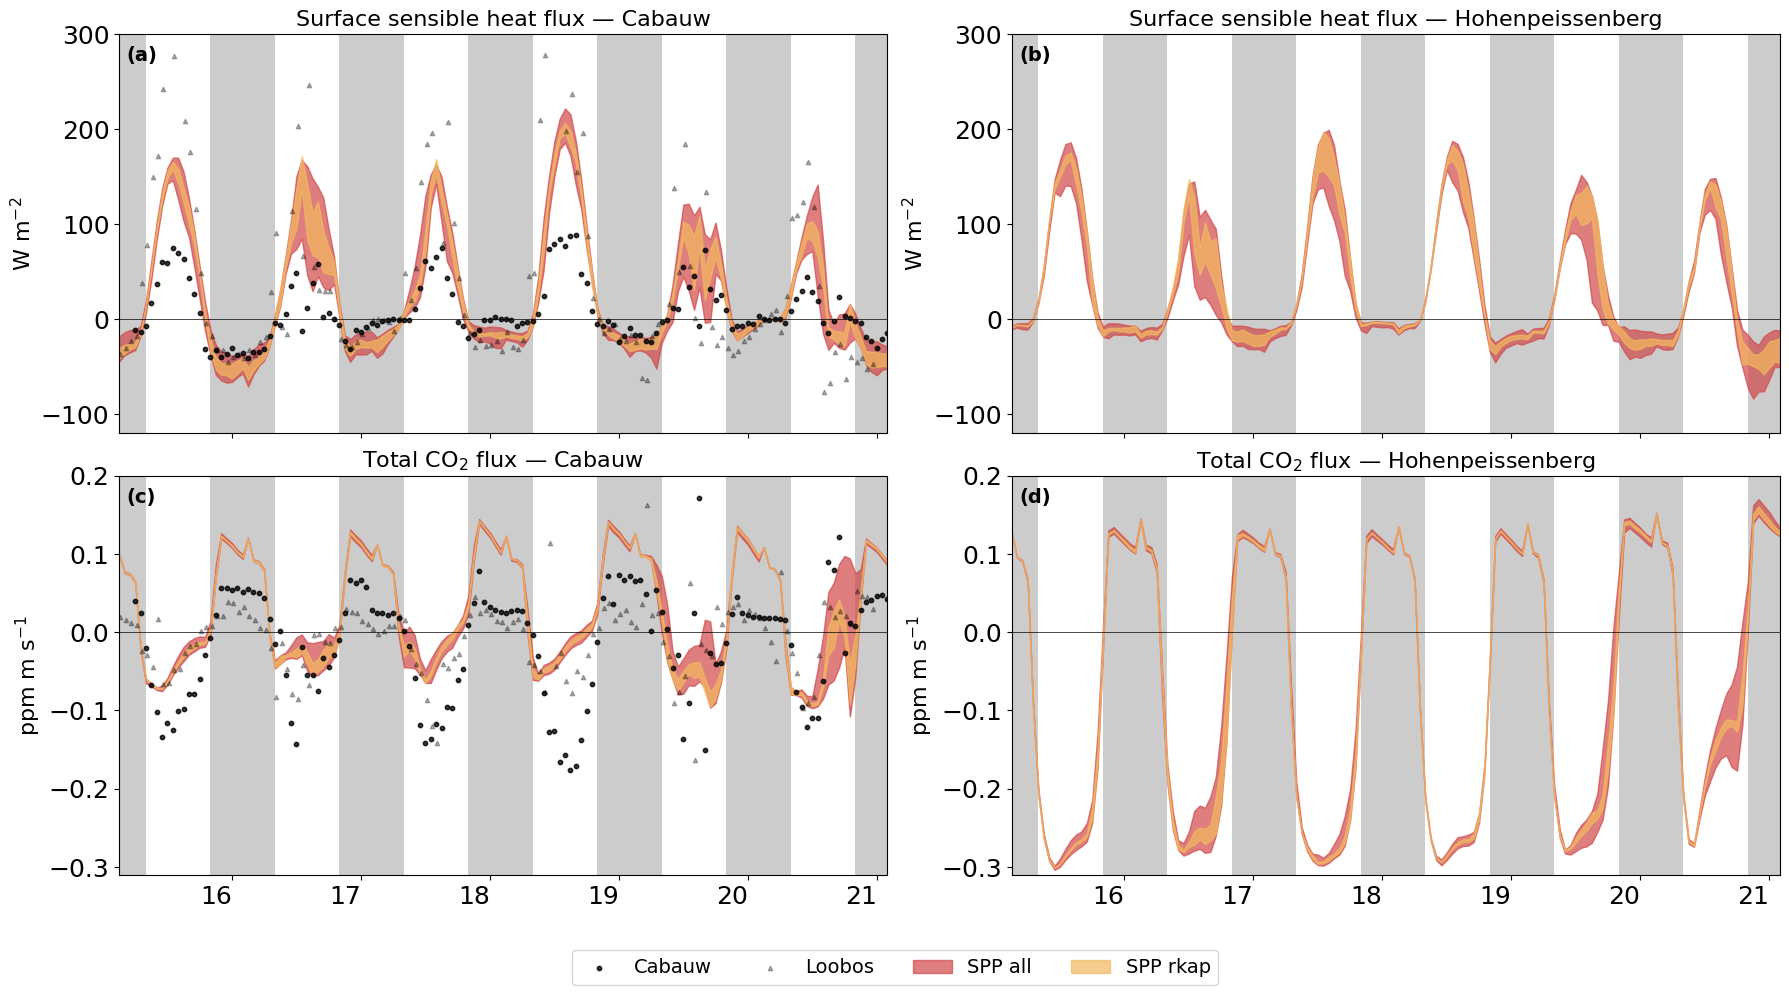

/etc/ecmwf/nfs/dh1_home_a/paaa/venv/test_env/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/etc/ecmwf/nfs/dh1_home_a/paaa/venv/test_env/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/etc/ecmwf/nfs/dh1_home_a/paaa/venv/test_env/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/etc/ecmwf/nfs/dh1_home_a/paaa/venv/test_env/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/etc/ecmwf/nfs/dh1_home_a/paaa/venv/test_env/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/etc/ecmwf/nfs/dh1_home_a/paaa/venv/test_env/lib/python3.11/site-packa

In [26]:
## ---- FIGURE 3 ---- ##
## Time series: H and total CO2 flux at Netherlands slab and HPB slab
# ── Settings ──────────────────────────────────────────────────────────────────
eps_exps_plot  = ['SPP_all_30', 'SPP_rkap_30']   # shaded envelopes (IFS_nemo)
line_exps_plot = ['9km_49r2b']                    # single line (IFS; not yet available for slab_hpb)

sites_info = [
    ('slab_nl',  'Cabauw--Loobos'),
    ('slab_hpb', 'Hohenpeissenberg'),
]
vars_info = [
    ('H',          'Surface sensible heat flux', 'W m$^{-2}$'),
    ('co2flx_tot', 'Total CO$_2$ flux',           'ppm m s$^{-1}$'),
]

def get_slab_var(srf_ds, var):
    """Extract and unit-convert H or co2flx_tot from a slab srf dataset."""
    if var == 'H':
        return -srf_ds['sshf'] / 3600
    ##########################################################################################    
    ###### !!!! The deaccumulation will not be needed anymore becasue already deaccumulated during the extraction ###### 
    ##### you still need to convett to ppm if needed
    elif var == 'co2flx_tot':
        rho = 1.245  # kg m-3, air density
        da_acc = srf_ds['co2flx_tot']
        # Deaccumulate: diff along time, then fix the daily restart at 03:00
        # At restart times the diff is wrong; replace with the raw accumulated value
        # (= amount accumulated in that first step of the new forecast cycle)
        d_da = da_acc.diff('time')
        restart_mask = da_acc['time'].isel(time=slice(1, None)).dt.hour == 3
        d_da_fixed = d_da.where(~restart_mask, other=da_acc.isel(time=slice(1, None)))
        da_deacc = xr.concat([da_acc.isel(time=0), d_da_fixed], dim='time') / 3600
        return -mfun.concentration_to_ppm('co2', da_deacc / rho)
    ##############################################################################
    ##########################################################################################

# ── Figure: 2 rows × 2 columns ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
panel_letters = [['a', 'b'], ['c', 'd']]

for icol, (site, site_label) in enumerate(sites_info):
    for irow, (var, var_title, var_units) in enumerate(vars_info):
        ax = axes[irow, icol]

        # --- Observations (only for slab_nl) ---------------------------------
        if site == 'slab_nl':
            if var == 'H':
                ax.scatter(ds_cabauw['obs_surf_flx']['time'],
                           ds_cabauw['obs_surf_flx']['H'],
                           c='k', s=10, label='Cabauw', alpha=0.8, zorder=5)
                ax.scatter(ds_loobos['Fluxes']['time'].resample(time='1h').mean(),
                           ds_loobos['Fluxes']['H'].resample(time='1h').mean(),
                           c='k', s=10, marker='^', label='Loobos', alpha=0.3, zorder=5)
            elif var == 'co2flx_tot':
                _flx_cb = mfun.concentration_to_ppm('co2', ds_cabauw['obs_surf_flx']['FC'] / 1000)
                ax.scatter(ds_cabauw['obs_surf_flx']['time'], _flx_cb / 3600,
                           c='k', s=10, label='Cabauw', alpha=0.8, zorder=5)
                _flx_lb = mfun.concentration_to_ppm('co2', ds_loobos['Fluxes']['co2_flux'] / 1000).resample(time='1h').mean()
                ax.scatter(ds_loobos['Fluxes']['time'].resample(time='1h').mean(),
                           _flx_lb / 3600,
                           c='k', s=10, marker='^', label='Loobos', alpha=0.3, zorder=5)

        # --- SPP ensemble shading --------------------------------------------
        for eps_exp, _, eps_label, eps_color in nemo_exp_names:
            if eps_exp not in eps_exps_plot:
                continue
            try:
                da = get_slab_var(IFS_nemo[site]['srf'][eps_exp], var).  # !!! attention, deaccumulation already done when extracting the data 
                if 'number' in da.dims:
                    ax.fill_between(da['time'].values,
                                    da.min('number').values,
                                    da.max('number').values,
                                    color=eps_color, alpha=0.7, label=eps_label)
            except Exception:
                pass

        # # --- Deterministic line (9km_49r2b; not yet available for slab_hpb) -
        # for exp, _, label, color in exp_names:
        #     if exp not in line_exps_plot:
        #         continue
        #     try:
        #         da = get_slab_var(IFS[site]['srf'][exp], var)
        #         da.plot(x='time', ax=ax, label=label, c=color, lw=2.0)
        #     except Exception:
        #         pass

        # --- Night shading ---------------------------------------------------
        ax.axhline(0, color='black', linewidth=0.5)
        for _mn in _midnights:
            ax.axvspan(_mn, _mn + timedelta(hours=night_hours[0]),
                       color='grey', alpha=0.4, zorder=0, linewidth=0)
            ax.axvspan(_mn + timedelta(hours=night_hours[1]), _mn + timedelta(hours=24),
                       color='grey', alpha=0.4, zorder=0, linewidth=0)

        ax.set_xlim(t0, t1)
        ax.set_xlabel('')
        ax.set_ylabel(var_units, fontsize=16)
        ax.set_title(f'{var_title} — {site_label}', fontsize=16)
        ax.text(0.01, 0.97, f'({panel_letters[irow][icol]})', transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')

for ii in [0, 1]:
    axes[0, ii].set_ylim([-120, 300])
    axes[1, ii].set_ylim([-0.31, 0.2])

# X-axis: show only the date on the bottom row (no hour/minute clutter)
import matplotlib.dates as mdates
for ax in axes[-1, :]:
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
    plt.setp(ax.xaxis.get_majorticklabels(),  ha='right')

# Shared legend (Cabauw / Loobos appear only once, deduplicated across panels)
_handles, _labels = [], []
for ax in axes.flat:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in _labels:
            _handles.append(h)
            _labels.append(l)
fig.legend(_handles, _labels, loc='lower center', bbox_to_anchor=(0.5, 0.0),
           ncol=min(len(_labels), 6), fontsize=14, frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
fig.savefig(f'{dir_out}/surface_H_and_CO2_fluxes_time_series.png', dpi=300)
plt.show()


Experiment ctrl_49r2b: 66 common time steps for slab_nl (day)
Experiment ctrl_49r2b: 66 common time steps with Loobos (day)
Experiment 9km_49r2b: 66 common time steps for slab_nl (day)
Experiment 9km_49r2b: 66 common time steps with Loobos (day)
Experiment short_tail_ABL: 66 common time steps for slab_nl (day)
Experiment short_tail_ABL: 66 common time steps with Loobos (day)
Experiment dryMF_49r2b: 66 common time steps for slab_nl (day)
Experiment dryMF_49r2b: 66 common time steps with Loobos (day)
Experiment ctrl_49r2b: 72 common time steps for slab_nl (night)
Experiment ctrl_49r2b: 69 common time steps with Loobos (night)
Experiment 9km_49r2b: 72 common time steps for slab_nl (night)
Experiment 9km_49r2b: 69 common time steps with Loobos (night)
Experiment short_tail_ABL: 72 common time steps for slab_nl (night)
Experiment short_tail_ABL: 69 common time steps with Loobos (night)
Experiment dryMF_49r2b: 72 common time steps for slab_nl (night)
Experiment dryMF_49r2b: 69 common time st

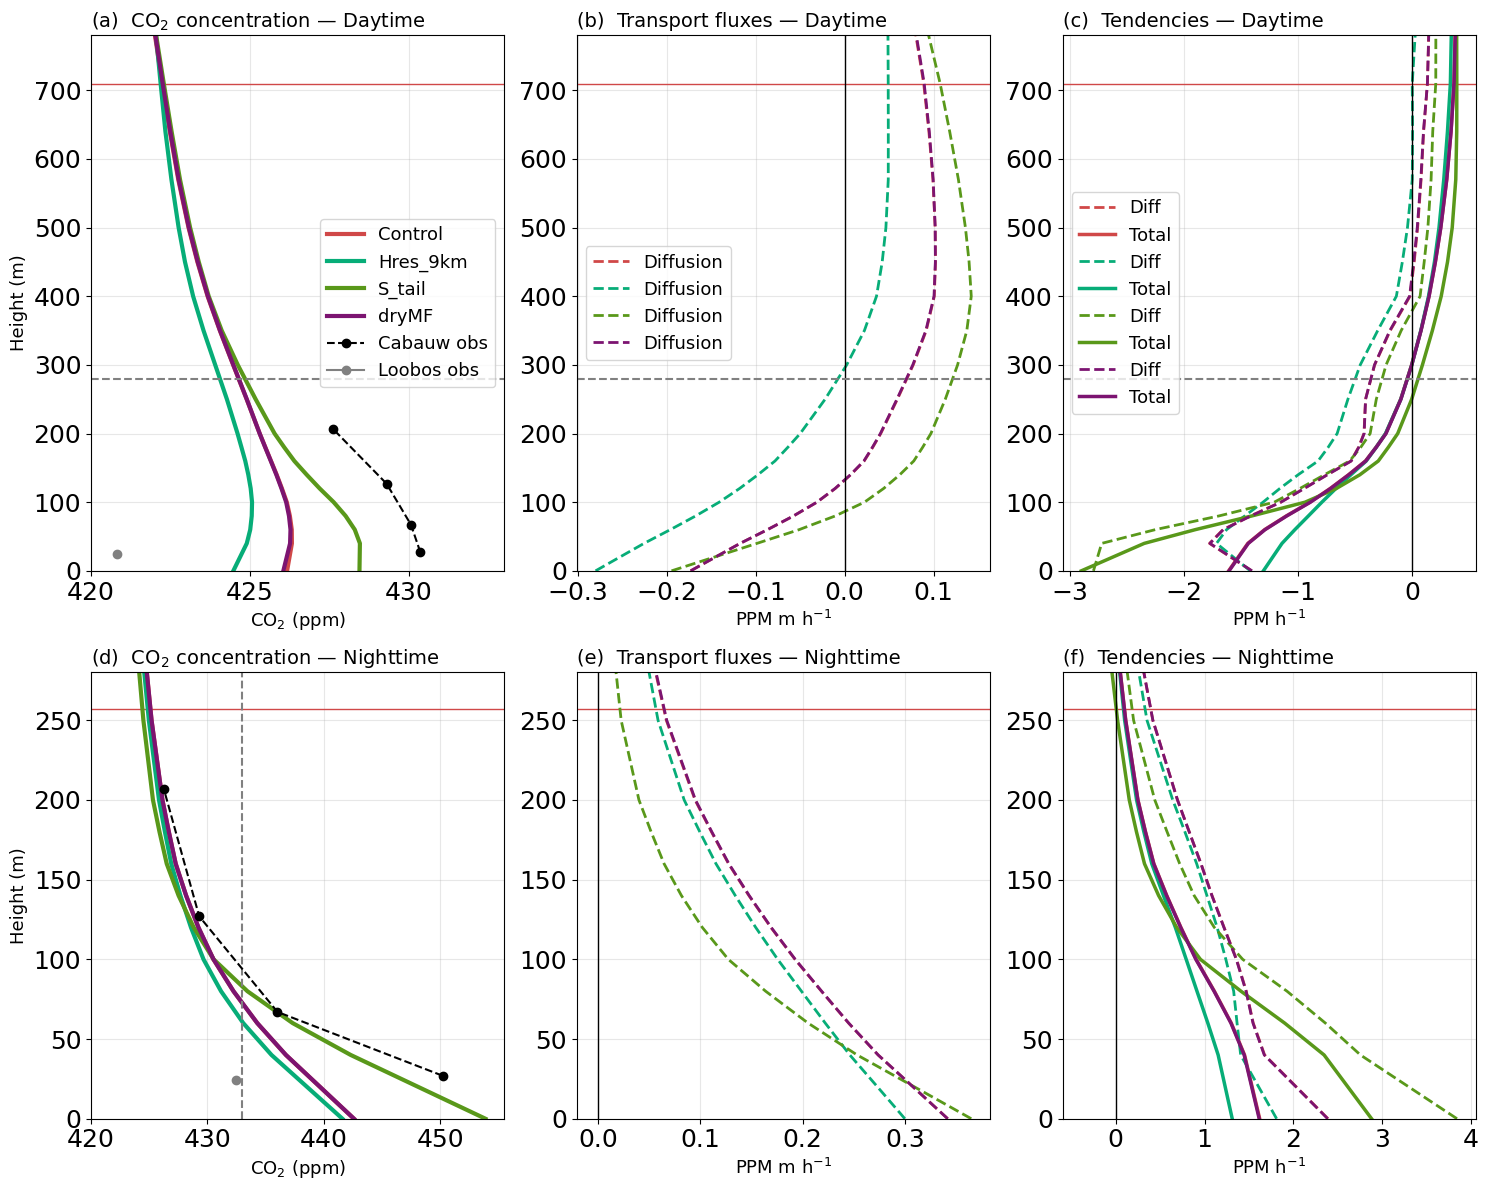

In [ ]:
## ---- FIGURE 4 ---- ## 
## ---- FIGURE 6 ---- ##
### Flux profiles and Budgets — Day (top) & Night (bottom) ###
var = 'co2'
spp_var = 'co2_ppm'

plot_exps = ['ctrl_49r2b','half_diff_stable','half_diff_unstable','9km_49r2b','short_tail_ABL']
plot_exps = ['ctrl_49r2b','dryMF_49r2b','short_tail_ABL','9km_49r2b'] 
plot_spp_exps = []


# site_key = 'cabauw'
site_key = 'slab_nl'
# site_key = 'loobos'
# site_key = 'HPB_tower'
# site_key = 'slab_hpb'

plot_dales = False
plot_loobos = True
loobos_height = 24
ylim_day = 780
ylim_night = 280
if site_key == 'cabauw' or site_key == 'slab_nl' or site_key == 'loobos':
    min_concentration_common = 420
    # min_concentration_common = None
    max_concentration_day = 433
elif site_key == 'HPB_tower' or site_key == 'slab_hpb':
    min_concentration_common = 412
    max_concentration_day = 423



row_configs = [
    ("Daytime",  "day",   day_hours),
    ("Nighttime","night", night_hours),
]

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- 2x3 figure ---
fig, all_axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 12),gridspec_kw={'height_ratios': [1.2, 1.0]})

for irow, (row_title, time_selection, daytime) in enumerate(row_configs):
    axes = all_axes[irow]

    # --- Set ylim based on day/night (must be done unconditionally) ---
    if time_selection == "day":
        ylim = ylim_day
    elif time_selection == "night":
        ylim = ylim_night

    # --- Filter observations for this row ---
    if site_key == 'cabauw' or site_key == 'slab_nl' or site_key == 'loobos':
        obs_ds_row = ds_cabauw['Cabauw_CO2_May2022']
        obs_flx_row = mfun.concentration_to_ppm(
            'co2', -ds_cabauw['obs_tower_flx'][['FC005','FC060','FC100','FC180']] * 10**-6)
    if (site_key == 'slab_nl' and plot_loobos) or site_key == 'loobos':
        obs_ds_row_2 = ds_loobos['Air_Quality']['co2_mixing_ratio']

    if site_key == 'HPB_tower' or site_key == 'slab_hpb':
        obs_ds_row = ds_towers.sel(station='hpb_surface-insitu')['CO2_obs']

    if site_key == 'cabauw' or site_key == 'slab_nl' or site_key == 'HPB_tower' or site_key == 'slab_hpb' or site_key == 'loobos':
        if time_selection == "day":
            obs_ds_row  = obs_ds_row.sel(time=obs_ds_row['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            # obs_flx_row = obs_flx_row.sel(time=obs_flx_row['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            if plot_dales:
                ds_dales_row = dales_cabauw.sel(time=dales_cabauw['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            if plot_loobos:
                obs_ds_row_2 = obs_ds_row_2.sel(time=obs_ds_row_2['time'].dt.hour.isin(range(daytime[0], daytime[1])))
        elif time_selection == "night":
            obs_ds_row  = obs_ds_row.sel(time=~obs_ds_row['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            # obs_flx_row = obs_flx_row.sel(time=~obs_flx_row['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            if plot_dales:
                ds_dales_row = dales_cabauw.sel(time=~dales_cabauw['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            if plot_loobos:
                obs_ds_row_2 = obs_ds_row_2.sel(time=~obs_ds_row_2['time'].dt.hour.isin(range(daytime[0], daytime[1])))

        obs_time = obs_ds_row['time']

    spp_plotted = False

    # --- Loop through experiments ---
    for exp, exp_longname, label, color in exp_names:
        if exp not in plot_exps:
            continue

        ds = IFS[site_key]['z'][exp]
        ds_srf = IFS[site_key]['srf'][exp]

        if time_selection == "day":
            ds     = ds.sel(time=ds['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            ds_srf = ds_srf.sel(time=ds_srf['time'].dt.hour.isin(range(daytime[0], daytime[1])))
        elif time_selection == "night":
            ds     = ds.sel(time=~ds['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            ds_srf = ds_srf.sel(time=~ds_srf['time'].dt.hour.isin(range(daytime[0], daytime[1])))

        if site_key == 'cabauw' and plot_dales:
            common_times = np.intersect1d(
                np.intersect1d(ds['time'].values, obs_time.values),
                ds_dales_row['time'].values)
            ds     = ds.sel(time=common_times)
            ds_srf = ds_srf.sel(time=common_times)
            ds_dales_row = ds_dales_row.sel(time=common_times)
        elif site_key == 'cabauw' or site_key == 'slab_nl' or site_key == 'slab_hpb' or site_key == 'HPB_tower' or site_key == 'loobos':
            common_times = np.intersect1d(ds['time'].values, obs_time.values)
            ds     = ds.sel(time=common_times)
            ds_srf = ds_srf.sel(time=common_times)
            print(f"Experiment {exp}: {len(common_times)} common time steps for {site_key} ({time_selection})")
        
        if (plot_loobos and site_key == 'slab_nl') or site_key == 'loobos':
            common_times = np.intersect1d(common_times, obs_ds_row_2['time'].values)
            obs_ds_row_2 = obs_ds_row_2.sel(time=common_times)
            obs_ds_row = obs_ds_row.sel(time=common_times)
            ds     = ds.sel(time=common_times)
            ds_srf = ds_srf.sel(time=common_times)
            print(f"Experiment {exp}: {len(common_times)} common time steps with Loobos ({time_selection})")


        # SPP envelope
        if (not spp_plotted) and len(plot_spp_exps) > 0:
            spp_exp = plot_spp_exps[0]
            spp_ds = IFS_nemo.get(site_key, {}).get('z', {}).get(spp_exp, None)
            if spp_ds is not None and (spp_var in spp_ds):
                if time_selection == "day":
                    spp_ds = spp_ds.sel(time=spp_ds['time'].dt.hour.isin(range(daytime[0], daytime[1])))
                elif time_selection == "night":
                    spp_ds = spp_ds.sel(time=~spp_ds['time'].dt.hour.isin(range(daytime[0], daytime[1])))
                if site_key == 'cabauw' or site_key == 'slab_nl':
                    spp_ds = spp_ds.sel(time=common_times)
                spp_mean = spp_ds[spp_var].sel(height=slice(0, ylim)).mean('time')
                if 'number' in spp_mean.dims:
                    spp_min = spp_mean.min('number')
                    spp_max = spp_mean.max('number')
                    spp_color = next((t[3] for t in nemo_exp_names if len(t) >= 4 and t[0] == spp_exp), 'grey')
                    spp_label = next((t[2] for t in nemo_exp_names if len(t) >= 3 and t[0] == spp_exp), 'SPP')
                    axes[0].fill_betweenx(
                        spp_min['height'].values, spp_min.values, spp_max.values,
                        color=spp_color, alpha=0.16, label=spp_label)
                    spp_plotted = True

        # Concentration profile
        ds[var].mean('time').plot(
            y='height', ax=axes[0], label=f'{label}', color=color, lw=3)
        if exp == 'ctrl_49r2b':
            axes[0].axhline(ds_srf['blh'].mean('time'), color=color, lw=1)

        # Flux profiles
        if exp == 'ctrl_49r2b':
            axes[1].axhline(ds_srf['blh'].mean('time'), color=color, lw=1)
        # (-ds[f'{var}flx_conv']).mean('time').plot(
        #     y='height', ax=axes[1], label='Convection', color=color, linestyle=':', lw=2)
        (-ds[f'{var}flx_diff']).mean('time').plot(
            y='height', ax=axes[1], label='Diffusion', color=color, linestyle='--', lw=2)
        # ds[f'{var}flx_dyn'].mean('time').plot(
        #     y='height', ax=axes[1], label='Dynamics', color=color, linestyle='-.', lw=2)
        # (-ds[f'{var}flx_diff']-ds[f'{var}flx_conv']+ds[f'{var}flx_dyn']).mean('time').plot(
        #     y='height', ax=axes[1], label='Total', color=color, linestyle='-', lw=1.4)

        # Tendencies
        if exp == 'ctrl_49r2b':
            axes[2].axhline(ds_srf['blh'].mean('time'), color=color, lw=1)
        ds[f'd{var}dt_diff'].mean('time').plot(
            y='height', ax=axes[2], label='Diff', color=color, linestyle='--', lw=2)
        # ds[f'd{var}dt_dyn'].mean('time').plot(
        #     y='height', ax=axes[2], label='Dyn', color=color, linestyle='-.', lw=2)
        (ds[f'd{var}dt_diff'] + ds[f'd{var}dt_conv'] + ds[f'd{var}dt_dyn']).mean('time').plot(
            y='height', ax=axes[2], label='Total', color=color, linestyle='-', lw=2.5)

    # --- Observations ---
    if site_key == 'cabauw' or site_key == 'slab_nl' or site_key == 'loobos':
        obs_mean = obs_ds_row.sel(time=common_times).mean('time')
        obs_conc = np.array([obs_mean[f'co2_{z}m'].values for z in cabauw_heights])
        axes[0].plot(obs_conc, cabauw_heights, 'ko--', label='Cabauw obs', zorder=5)

        tend_vars = [f'dco2dt_{z}' for z in cabauw_heights if f'dco2dt_{z}' in obs_mean]
        if tend_vars:
            obs_tend = np.array([obs_mean[v].values for v in tend_vars])
            tend_heights = [int(v.split('_')[-1].replace('m', '')) for v in tend_vars]
            axes[2].plot(obs_tend, tend_heights, 'ko--', label='Cabauw obs', zorder=5)
    elif site_key == 'HPB_tower' or site_key == 'slab_hpb':
        # obs_mean = obs_ds_row.mean('time').dropna('height')
        # obs_mean.plot(y='height', ax=axes[0], label='HPB obs',
        #                                               lw=2, color='k', marker='o', linestyle='--',zorder=5)
        obs_ds_row.mean('time').dropna('height').plot(
            y='height', ax=axes[0], label='HPB obs',
            lw=2, color='k', marker='o', linestyle='--', zorder=5)
        axes[0].set_title("")


    # --- DALES ---
    if site_key == 'cabauw' and plot_dales:
        dales_ppm = ds_dales_row['sv004_ppm'].mean('time')
        dales_ppm.plot(ax=axes[0], y='zt', lw=2, label='DALES')

    # --- Loobos ---
    if (site_key == 'slab_nl' and plot_loobos) or site_key == 'loobos':
        obs_mean_2 = obs_ds_row_2.mean('time')
        axes[0].plot(obs_mean_2, loobos_height, color='grey',  marker='o', label='Loobos obs', zorder=5)

    # --- Axis styling ---
    unit_tend = ds[f'd{var}dt_tot'].attrs.get("units", " ")
    unit_flx  = ds[f'{var}flx_conv'].attrs.get("units", "ppm m h$^{-1}$")

    axes[0].set_ylim([0, ylim])
    axes[0].set_xlabel('CO$_2$ (ppm)', fontsize=13)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title(
        f'{panel_labels[irow*3]}  CO$_2$ concentration \u2014 {row_title}',
        fontsize=14, loc='left')
    axes[0].set_ylabel('Height (m)', fontsize=13)

    axes[1].axvline(0, c='k', lw=1)
    axes[1].set_ylim([0, ylim])
    axes[1].set_xlabel(unit_flx, fontsize=13)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylabel('')
    axes[1].set_title(
        f'{panel_labels[irow*3+1]}  Transport fluxes \u2014 {row_title}',
        fontsize=14, loc='left')

    axes[2].axvline(0, c='k', lw=1)
    axes[2].set_ylim([0, ylim])
    axes[2].set_xlabel(unit_tend, fontsize=13)
    axes[2].set_ylabel('')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_title(
        f'{panel_labels[irow*3+2]}  Tendencies \u2014 {row_title}',
        fontsize=14, loc='left')

    # Legend only on top row
    if irow == 0:
        axes[0].legend(fontsize=13, loc='center right')
        axes[1].legend(fontsize=13, loc='center left')
        axes[2].legend(fontsize=13, loc='center left')

all_axes[0,0].set_xlim([min_concentration_common,max_concentration_day])
all_axes[1,0].set_xlim([min_concentration_common,None])

if site_key == 'HPB_tower' or site_key == 'slab_hpb':
    all_axes[0,1].set_xlim([-1.26,-0.43])
    # all_axes[0,1].set_xlim([-0.9,-0.29])
    all_axes[1,1].set_xlim([-0.15, 0.57])

all_axes[0,0].axhline(ylim_night, color='grey', ls='--')
all_axes[0,1].axhline(ylim_night, color='grey', ls='--')
all_axes[0,2].axhline(ylim_night, color='grey', ls='--')

all_axes[1,0].axvline(max_concentration_day, color='grey', ls='--')


plt.tight_layout()
fig.savefig(f'{dir_out}/{var}_profiles_{site_key}_day_night.png', dpi=300)
plt.show()


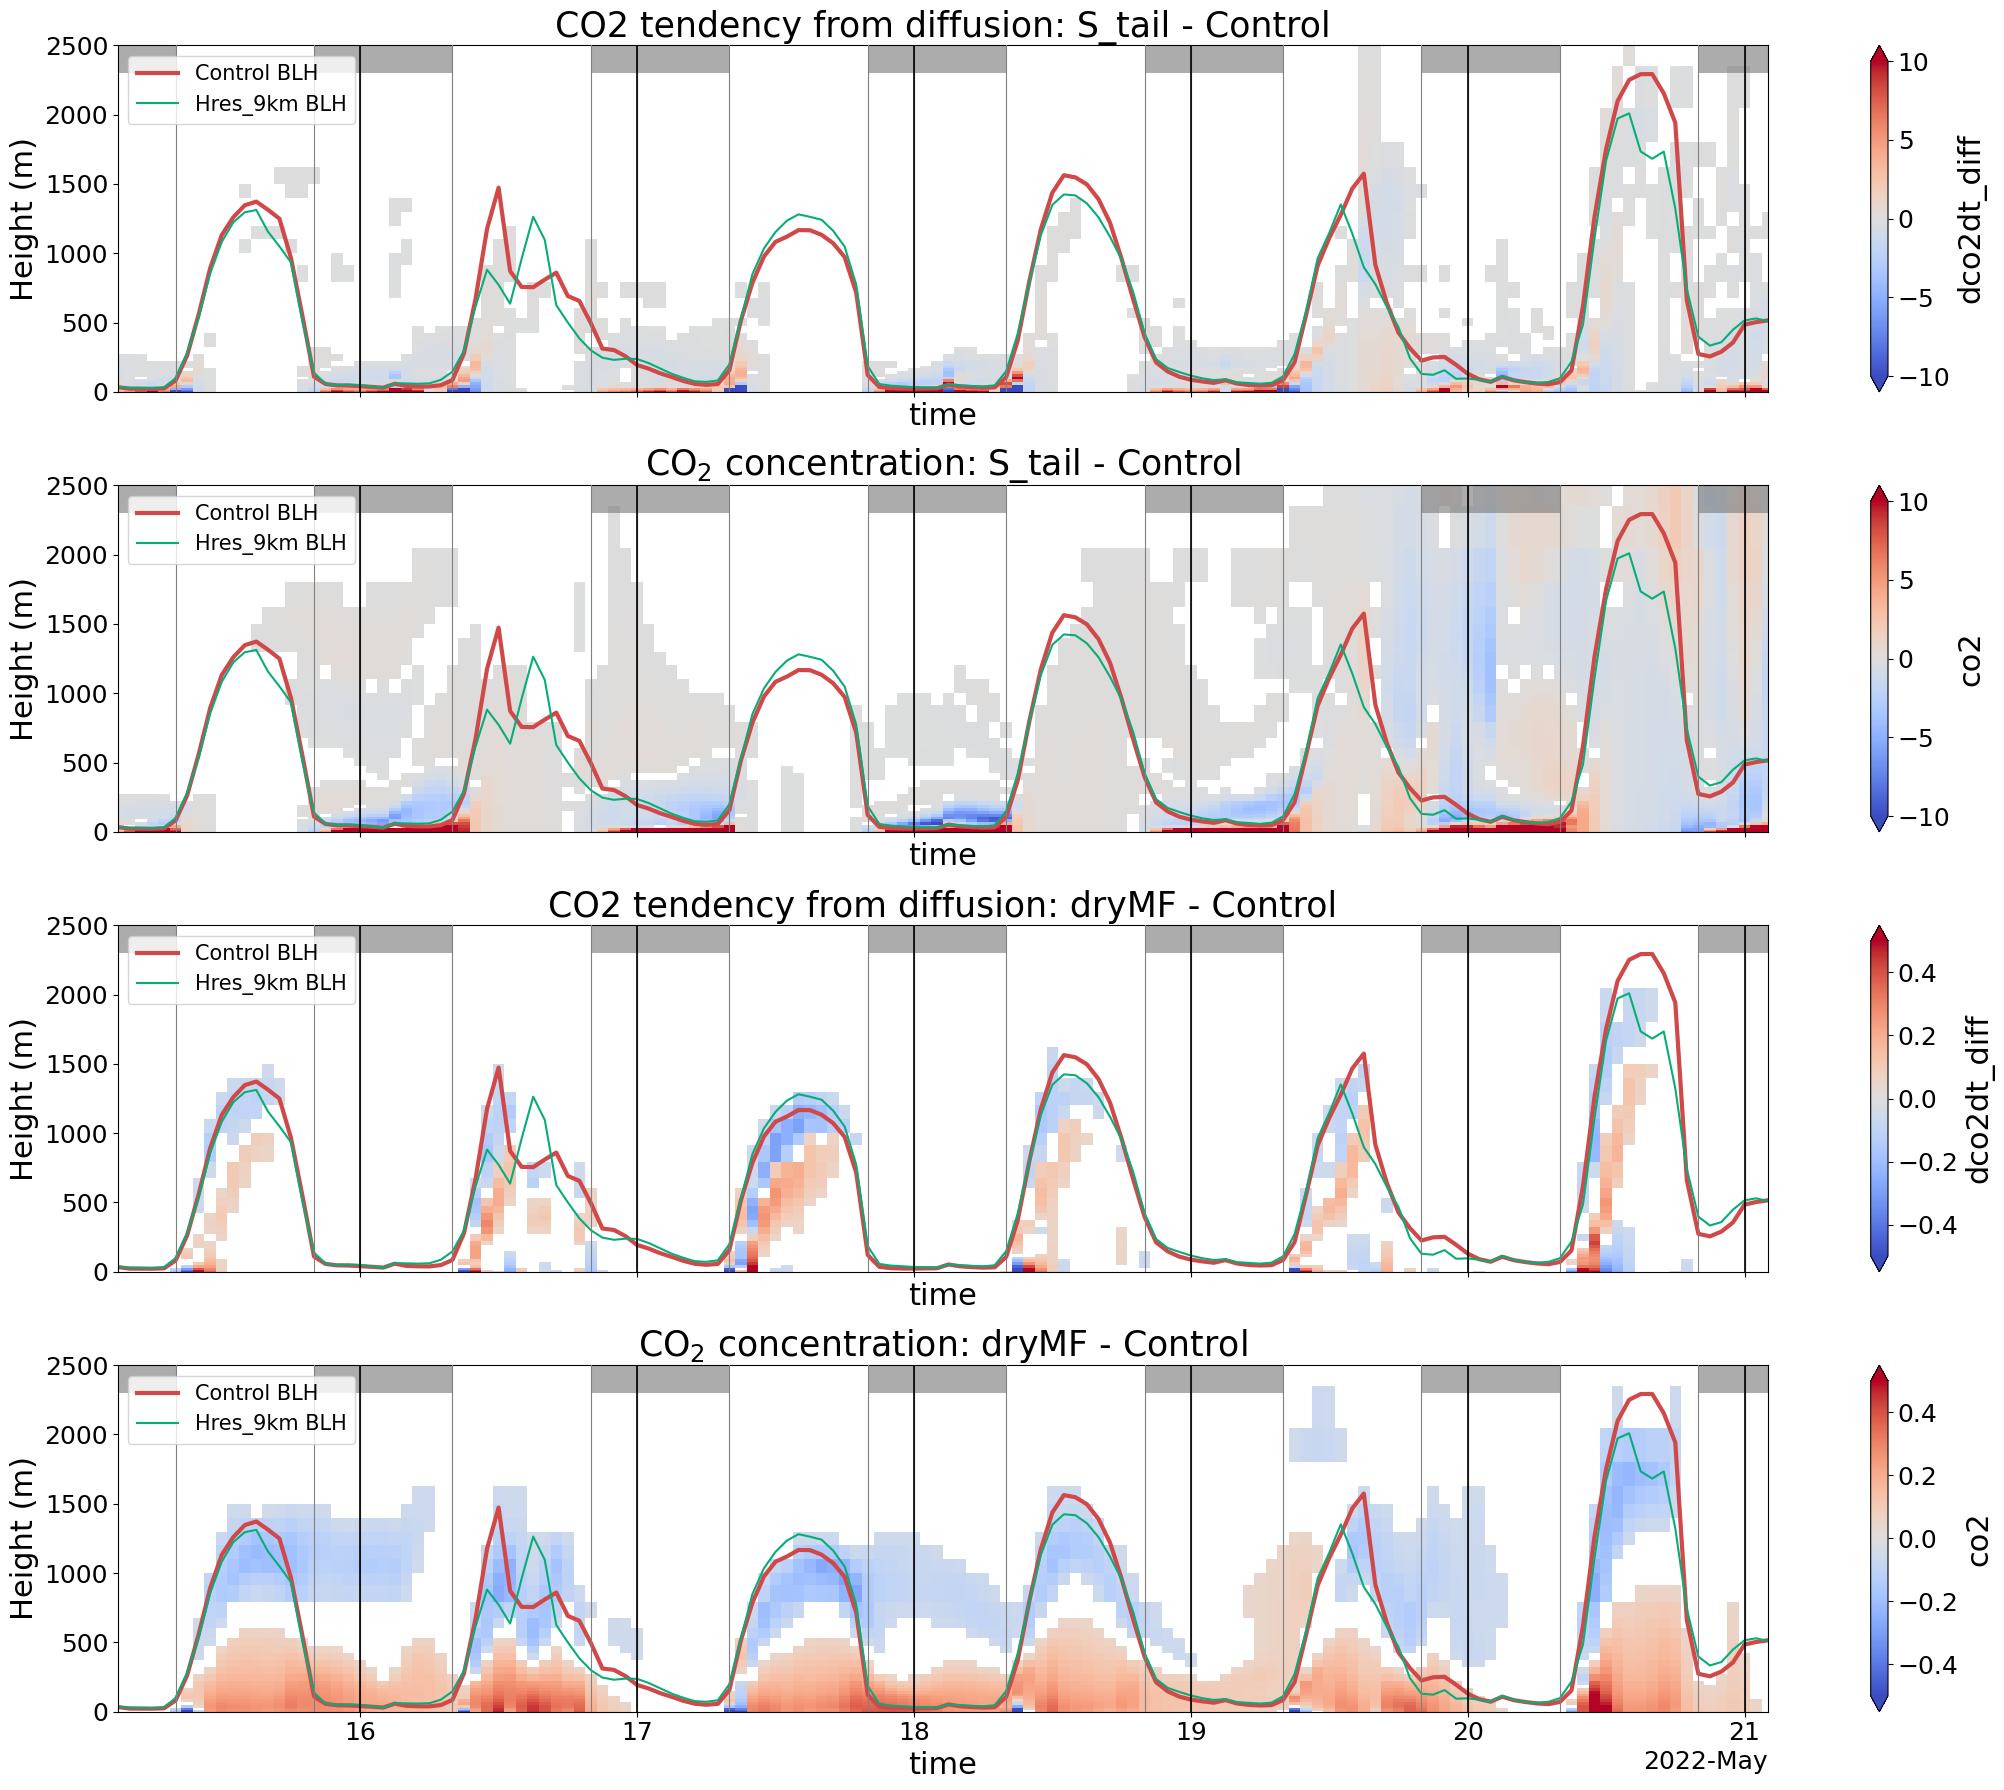

In [73]:
## ---- FIGURE 5 ---- ##
##############################################
#####   Difference between experiments  #####
##############################################

# Experiments to compare
exp1 = 'ctrl_49r2b'
exp2 = [ 'half_diff_unstable','half_diff_stable','short_tail_ABL','dryMF_49r2b']
exp2 = ['short_tail_ABL','dryMF_49r2b']


location ='cabauw'
# location ='HPB_tower'
location ='slab_hpb'
add_loobos = False

# Variables to plot: (variable_name, plot title)
vars_to_plot = [
    # ('dco2dt_dyn',  'CO2 tendency from dynamics'),
    # ('dco2dt_conv', 'CO2 tendency from convection'),
    ('dco2dt_diff', 'CO2 tendency from diffusion', 'ppm h$^{-1}$'),
    # ('co2flx_diff', 'CO2 flux from diffusion'),
    ('co2', r'CO$_2$ concentration', 'ppm'),
    # ('clwc', 'cloud liquid water'),
    # ('T', 'Temperature'),
]

# Colormap limits (set to None for automatic scaling)
vmin_1 = -10
vmax_1 = +10
vmin_2 = -0.5
vmax_2 = +0.5

n_rows = len(exp2) * len(vars_to_plot)

# Create a figure with rows equal to number of exp2 members * number of variables
fig, axes = plt.subplots(nrows=n_rows, ncols=1, figsize=(22, n_rows*4+2), sharex=True)

# Make sure axes is always iterable
if n_rows == 1:
    axes = [axes]

ax_idx = 0
# Loop through each exp2 experiment and each variable
for exp2_exp in exp2:
    if exp2_exp == 'short_tail_ABL':
        vmin, vmax = vmin_1, vmax_1
    else:
        vmin, vmax = vmin_2, vmax_2
    for var, title, cbar_label in vars_to_plot:
        ax = axes[ax_idx]
        ax_idx += 1

        # Calculate difference between experiments
        data_diff = IFS[location]['z'][exp2_exp][var] - IFS[location]['z'][exp1][var]

        masked = data_diff.where(np.abs(data_diff) >= 0.05)
        cmap = plt.get_cmap("coolwarm").copy()
        cmap.set_bad("white")

        # Norm centred exactly at 0 → 0 is always white
        norm_colors = mcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

        # Plot the difference
        masked.plot(
            ax=ax,
            y='height',
            cmap=cmap,
            norm=norm_colors,
            cbar_kwargs={'label': cbar_label}
        )

        # Add boundary layer height lines for both experiments
        for blh_exp in [exp1,'9km_49r2b']:
        # for blh_exp in [exp1]:
            if blh_exp =='ctrl_49r2b':
                lw =3
            else: lw=1.5
            blh_color = next((t[3] for t in exp_names if t[0] == blh_exp), 'k')
            blh_label = next((t[2] for t in exp_names if t[0] == blh_exp), blh_exp)
            IFS[location]['srf'][blh_exp]['blh'].plot(ax=ax, x='time', c=blh_color, lw=lw, label=f'{blh_label} BLH')

        if location == 'cabauw':
            blh_cabauw['MLH'].sel(station_name='CABAUW,NETHERLANDS            ').plot(ax=ax, c='g', ls='--', lw=2, label='STRATfinder MLH')

        if add_loobos:
            ds_loobos['BLH']['BLH_radio'].plot.scatter(ax=ax, c='k', alpha=0.3, label='Radiosondes', s=100, marker='d')
            ds_loobos['BLH']['BLH_plane'].plot.scatter(ax=ax, c='k',alpha=0.3, label='Plane', s=100, marker='o')

        # Formatting
        ax.set_ylim(0, 2500)
        ax.set_xlim(
            datetime.datetime.strptime(str_time, "%Y-%m-%dT%H:%M"),
            datetime.datetime.strptime(end_time, "%Y-%m-%dT%H:%M")
        )
        ax.set_ylabel('Height (m)')
        exp1_label = next((t[2] for t in exp_names if t[0] == exp1), exp1)
        exp2_label = next((t[2] for t in exp_names if t[0] == exp2_exp), exp2_exp)
        ax.set_title(f'{title}: {exp2_label} - {exp1_label}', fontsize=25)
        ax.legend(fontsize=15)
        ax.grid(axis='x')

        # Add nighttime indication: vertical black lines + shaded box between y=2250 and y=2500
        _ymin_frac = 2300 / 2500  # axes fraction for y=2250 when ylim=(0, 2500)
        for dt in _midnights:
            # Night period 1: 00:00 to night_hours[0]
            t0_n = dt
            t1_n = dt + timedelta(hours=night_hours[0])
            ax.axvline(t0_n, color='black', lw=1.2, zorder=3)
            ax.axvline(t1_n, color='grey', lw=0.8, zorder=3)
            ax.axvspan(t0_n, t1_n, ymin=_ymin_frac, ymax=1.0,
                    color='grey', alpha=0.65, zorder=2, linewidth=0)
            # Night period 2: night_hours[1] to 24:00
            t2_n = dt + timedelta(hours=night_hours[1])
            t3_n = dt + timedelta(hours=24)
            ax.axvline(t2_n, color='grey', lw=0.8, zorder=3)
            ax.axvline(t3_n, color='grey', lw=0.8, zorder=3)
            ax.axvspan(t2_n, t3_n, ymin=_ymin_frac, ymax=1.0,
                    color='grey', alpha=0.65, zorder=2, linewidth=0)

# Adjust layout for readability
plt.tight_layout()
plt.savefig(os.path.join(dir_out, f"diff_{exp1}_vs_{'_'.join(exp2)}.png"), dpi=300, bbox_inches='tight')


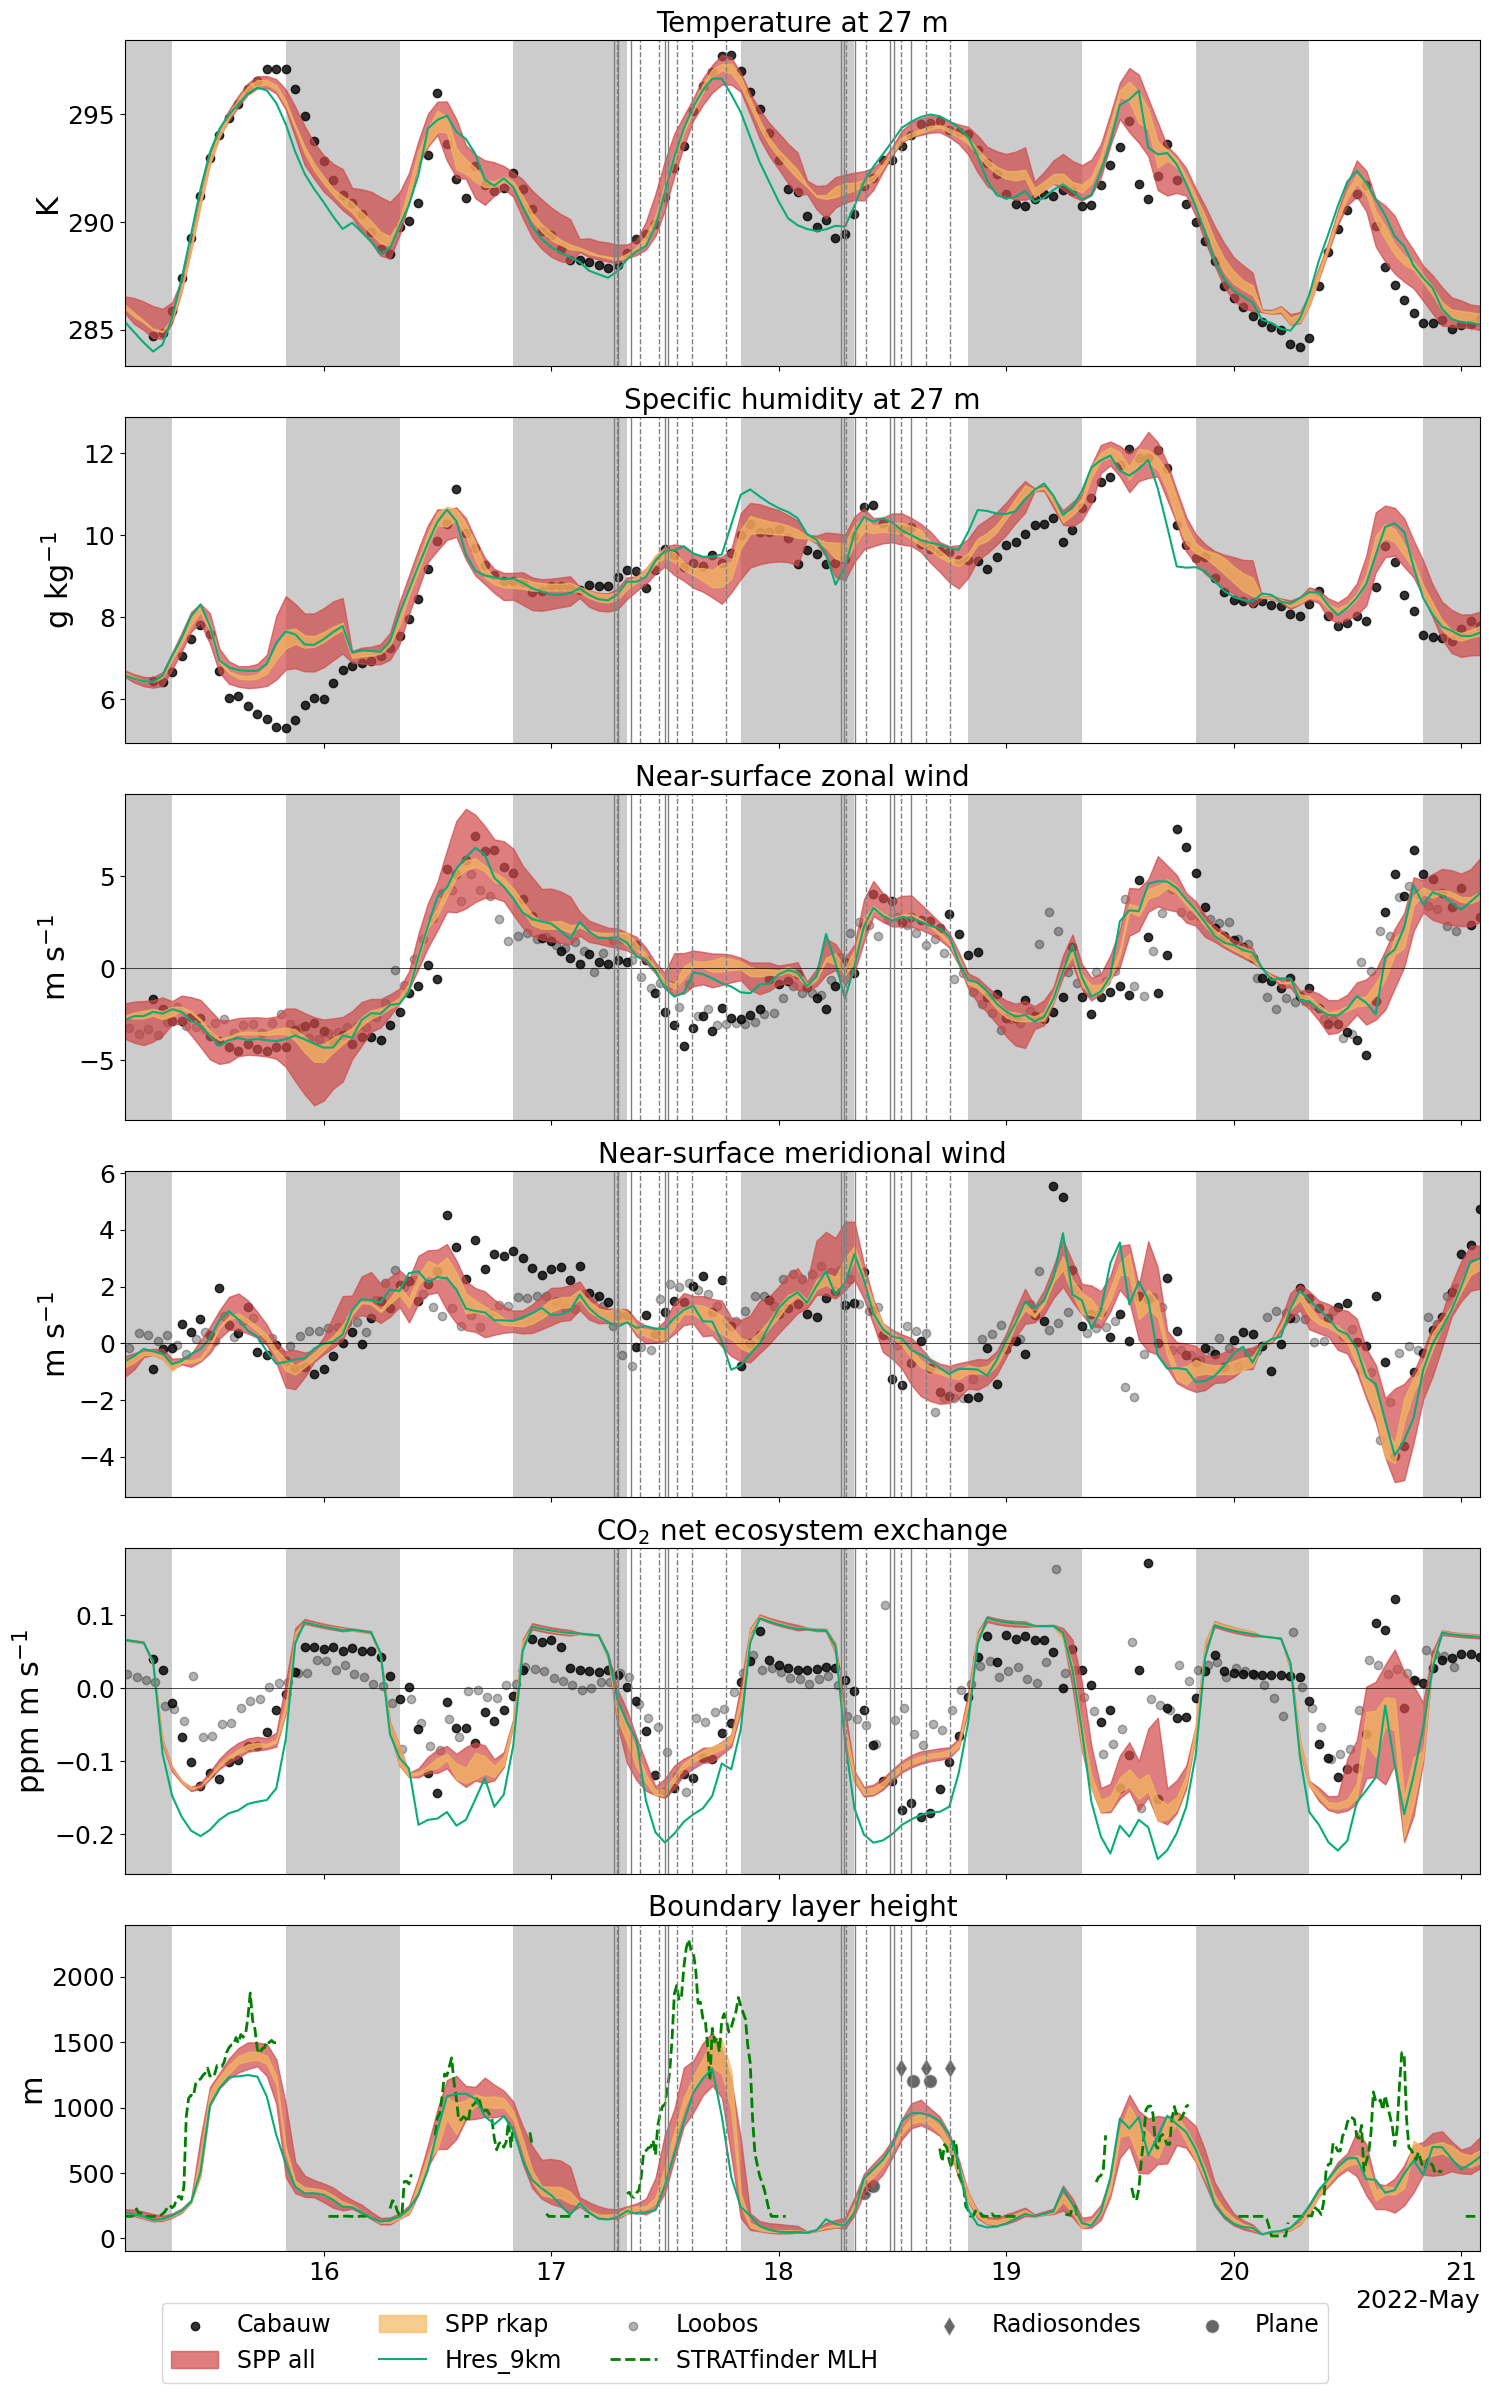

In [137]:
## ---- FIGURE 8 ---- ##
#####  Evolution of Standard variables at Cabauw  #####
################################################################

def nee_in_ppm(ds, exp, location='cabauw', var='fco2nee'):
    old_units = ds['3d_nl']['srf'][exp][var].attrs['units']
    try:
        p_surf = ds[location]['srf'][exp]['sp']
    except KeyError:
        p_surf = np.exp(ds[location]['z'][exp]['lnsp'])
    if 'kg m**-2 s**-1' in old_units:
        rho = 1.245
        ds[location]['srf'][exp][f'{var}_ppm'] = mfun.concentration_to_ppm('co2', ds[location]['srf'][exp][var] / rho)
        ds[location]['srf'][exp][f'{var}_ppm'].attrs['units'] = old_units.replace('kg m**-2$', 'PPM m/s')
    return ds[location]['srf'][exp][f'{var}_ppm']

# ── Settings ──────────────────────────────────────────────────────────────────
plot_exps     = ['9km_49r2b']   # can be empty []
plot_eps_exps = ['SPP_all_30','SPP_rkap_30']

location   = 'cabauw'
add_loobos = True
add_dales  = False
sel_z      = 27   # m (T, q, co2)
sel_z_wind = 10    # m (u, v)
# sel_z_wind = 27    # m (u, v)
vars = ['T', 'q', 'u', 'v', 'fco2nee', 'blh']

for exp in plot_exps:
    IFS[location]['srf'][exp]['fco2nee_ppm'] = nee_in_ppm(IFS, exp, location, var='fco2nee')
for exp in plot_eps_exps:
    IFS_nemo[location]['srf'][exp]['fco2nee_ppm'] = nee_in_ppm(IFS_nemo, exp, location, var='fco2nee')

# ── Helpers ───────────────────────────────────────────────────────────────────
def format_units(u):
    import re
    return re.sub(r'(\w+)\*\*(-?\d+)', lambda m: m.group(1) + '$^{' + m.group(2) + '}$', u)

_default_units = {
    'u': 'm s**-1', 'v': 'm s**-1', 'T': 'K', 'q': 'g kg**-1',
    'fco2nee': 'ppm m s$^{-1}$', 'H': 'W m$^{-2}$', 'co2': 'ppm',
    'blh': 'm',
}
_titles = {
    'u':       f"Zonal wind",
    'v':       f"Meridional wind",
    'T':       f"Temperature",
    'q':       f"Specific humidity",
    'fco2nee': "CO$_2$ net ecosystem exchange",
    'H':       "Surface sensible heat flux",
    'co2':     f"CO$_2$ at {sel_z} m",
    'blh':     "Boundary layer height",
}
# _titles = {
#     'u':       f"Near-surface zonal wind",
#     'v':       f"Near-surface meridional wind",
#     'T':       f"Temperature at {sel_z} m",
#     'q':       f"Specific humidity at {sel_z} m",
#     'fco2nee': "CO$_2$ net ecosystem exchange",
#     'H':       "Surface sensible heat flux",
#     'co2':     f"CO$_2$ at {sel_z} m",
#     'blh':     "Boundary layer height",
# }
# _titles = {
#     'u':       f"Zonal wind at {sel_z_wind} m",
#     'v':       f"Meridional wind at {sel_z_wind} m",
#     'T':       f"Temperature at {sel_z} m",
#     'q':       f"Specific humidity at {sel_z} m",
#     'fco2nee': "CO$_2$ net ecosystem exchange",
#     'H':       "Surface sensible heat flux",
#     'co2':     f"CO$_2$ at {sel_z} m",
#     'blh':     "Boundary layer height",
# }

def get_ifs_slab(ds_dict, exp, var, location, sel_z, sel_z_wind):
    """Return the data slice for a given variable from an IFS-style dict."""
    if var in ('fco2nee', 'fco2rec', 'fco2gpp'):
        return -ds_dict[location]['srf'][exp][f'{var}_ppm']
    elif var == 'H':
        return -ds_dict[location]['srf'][exp]['sshf'] / 3600
    elif var == 'blh':
        return ds_dict[location]['srf'][exp]['blh']
    elif var == 'u':
        return ds_dict[location]['srf'][exp]['u10']
    elif var == 'v':
        return ds_dict[location]['srf'][exp]['v10']
    elif var == 'T':
        return ds_dict[location]['z'][exp]['T'].sel(height=sel_z, method='nearest')
    elif var == 'q':
        return ds_dict[location]['z'][exp]['q'].sel(height=sel_z, method='nearest')
    else:
        return ds_dict[location]['z'][exp][var].sel(height=sel_z, method='nearest')

def get_nemo_slab(ds_dict, exp, var, location, sel_z, sel_z_wind):
    """Return the data slice for a NEMO (ensemble) experiment."""
    if var in ('fco2nee', 'fco2rec', 'fco2gpp'):
        return -ds_dict[location]['srf'][exp][f'{var}_ppm']
    elif var == 'H':
        return -ds_dict[location]['srf'][exp]['sshf'] / 3600
    elif var == 'blh':
        return ds_dict[location]['srf'][exp]['blh']
    elif var == 'u':
        return ds_dict[location]['srf'][exp]['u10']
    elif var == 'v':
        return ds_dict[location]['srf'][exp]['v10']
    elif var == 'T':
        return ds_dict[location]['z'][exp]['t'].sel(height=sel_z, method='nearest')
    elif var == 'q':
        return 1000 * ds_dict[location]['z'][exp]['q'].sel(height=sel_z, method='nearest')
    else:
        return ds_dict[location]['z'][exp][var].sel(height=sel_z, method='nearest')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(vars), 1, figsize=(15, 4 * len(vars)), sharex=True)
if len(vars) == 1:
    axes = [axes]

# DALES background lines
if add_dales: 
    _dales_data = {
        'T': dales_prof['thl'].sel(zt=sel_z, method='nearest'),
        'q': 1000 * dales_prof['qt'].sel(zt=sel_z, method='nearest'),
        'u': dales_cabauw['u'].sel(zt=sel_z_wind, method='nearest'),
        'v': dales_cabauw['v'].sel(zt=sel_z_wind, method='nearest'),
    }
    for var_key, da in _dales_data.items():
        if var_key in vars:
            da.plot(ax=axes[vars.index(var_key)], label='DALES', lw=2)

# ── Per-variable loop ──────────────────────────────────────────────────────────
for i, (ax, var) in enumerate(zip(axes, vars)):

    # Observations (Cabauw)
    if location == 'cabauw':
        if var == 'co2':
            heights_obs = np.array([27, 67, 127, 207])
            ch = heights_obs[np.abs(heights_obs - sel_z).argmin()]
            ax.scatter(ds_cabauw['Cabauw_CO2_May2022']['time'],
                       ds_cabauw['Cabauw_CO2_May2022'][f'co2_{ch}m'],
                       c='k', label='Cabauw', alpha=0.8)
        elif var == 'T':
            ax.scatter(ds_cabauw['obs_tower_meteo']['time'],
                       ds_cabauw['obs_tower_meteo']['TA'].sel(z=sel_z, method='nearest'),
                       c='k', label='Cabauw', alpha=0.8)
        elif var == 'q':
            ax.scatter(ds_cabauw['obs_tower_meteo']['time'],
                       ds_cabauw['obs_tower_meteo']['Q'].sel(z=sel_z, method='nearest'),
                       c='k', label='Cabauw', alpha=0.8)
        elif var in ('u', 'v'):
            ax.scatter(ds_cabauw['obs_tower_meteo']['time'],
                       ds_cabauw['obs_tower_meteo'][var].sel(z=sel_z_wind, method='nearest'),
                       c='k', alpha=0.8)
        elif var in ('fco2nee', 'fco2rec', 'fco2gpp'):
            srf_flx = mfun.concentration_to_ppm('co2', ds_cabauw['obs_surf_flx']['FC'] / 1000)
            ax.scatter(ds_cabauw['obs_surf_flx']['time'], srf_flx / 3600,
                       c='k', label='Cabauw', alpha=0.8)
        elif var == 'H':
            ax.scatter(ds_cabauw['obs_surf_flx']['time'], ds_cabauw['obs_surf_flx']['H'],
                       c='k', label='Cabauw', alpha=0.8)
        elif var == 'blh':
            blh_cabauw['MLH'].sel(station_name='CABAUW,NETHERLANDS            ').plot(
                ax=ax, c='k', ls='--', lw=2, label='STRATfinder MLH')

    # Observations (Loobos)
    if add_loobos:
        # if var in ('fco2nee', 'fco2rec', 'fco2gpp'):
        #     srf_flx_loobos = mfun.concentration_to_ppm('co2', ds_loobos['Fluxes']['co2_flux'] / 1000).resample(time='1h').mean()
        #     ax.scatter(ds_loobos['Fluxes']['time'].resample(time='1h').mean(), srf_flx_loobos / 3600,
        #                c='k', label='Loobos', alpha=0.3)
        if var == 'H':
            ax.scatter(ds_loobos['Fluxes']['time'].resample(time='1h').mean(),
                       ds_loobos['Fluxes']['H'].resample(time='1h').mean(),
                       c='k', label='Loobos', alpha=0.3)
        elif var == 'blh':
            ds_loobos['BLH']['BLH_radio'].plot.scatter(ax=ax, c='k', alpha=0.6, label='Radiosondes', s=100, marker='d')
            ds_loobos['BLH']['BLH_plane'].plot.scatter(ax=ax, c='k', alpha=0.6, label='Plane', s=100, marker='o')
        elif var in ('u', 'v'):
            ax.scatter(ds_loobos['Meteorology']['time'].resample(time='1h').mean(),
                       ds_loobos['Meteorology'][var].resample(time='1h').mean(),
                       c='k', alpha=0.3)

    # NEMO ensemble envelope
    for eps_exp, _, eps_label, eps_color in nemo_exp_names:
        if eps_exp not in plot_eps_exps:
            continue
        try:
            slab_nemo = get_nemo_slab(IFS_nemo, eps_exp, var, location, sel_z, sel_z_wind)
            if 'number' in slab_nemo.dims:
                ax.fill_between(slab_nemo['time'].values,
                                slab_nemo.min('number').values,
                                slab_nemo.max('number').values,
                                color=eps_color, alpha=0.7, label=eps_label)
        except Exception:
            pass

    # IFS deterministic experiments
    for exp, _, label, color in exp_names:
        if exp not in plot_exps:
            continue
        lw = 3.5 if exp == 'ctrl_49r2b' else 1.5
        try:
            slab = get_ifs_slab(IFS, exp, var, location, sel_z, sel_z_wind)
            slab.plot(x='time', ax=ax, label=label if i == 0 else None, c=color, lw=lw)
        except Exception:
            pass

    # Decorations
    if var in ('u', 'v', 'fco2nee', 'fco2rec', 'fco2gpp', 'H'):
        ax.axhline(0, color='black', linewidth=0.5)
    for dt in _midnights:
        ax.axvspan(dt, dt + timedelta(hours=night_hours[0]), color='grey', alpha=0.4, zorder=0, linewidth=0)
        ax.axvspan(dt + timedelta(hours=night_hours[1]), dt + timedelta(hours=24), color='grey', alpha=0.4, zorder=0, linewidth=0)
    for leg_key in midd_times:
        ax.axvline(midd_times[leg_key], c='grey', ls='-', lw=1)
    for radio_time in loobos_radio['time'].values:
        ax.axvline(radio_time, c='grey', ls='--', lw=1)

    # ax.set_xlim(t0 + timedelta(hours=24), t1)
    ax.set_xlim(t0, t1)

    ax.set_xlabel('')
    ax.set_ylabel(format_units(_default_units.get(var, '')))
    ax.set_title(_titles.get(var, var + f' at {sel_z} m'), fontsize=20)

# Shared legend
_handles, _labels = [], []
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in _labels:
            _handles.append(h)
            _labels.append(l)
fig.legend(_handles, _labels, loc='lower center', bbox_to_anchor=(0.5, 0.0),
           ncol=min(len(_labels), 5), fontsize=17, frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.06)
plt.savefig(os.path.join(dir_out, f"ctrl_timeseries_{location}_z{sel_z}m.png"), dpi=300, bbox_inches='tight')


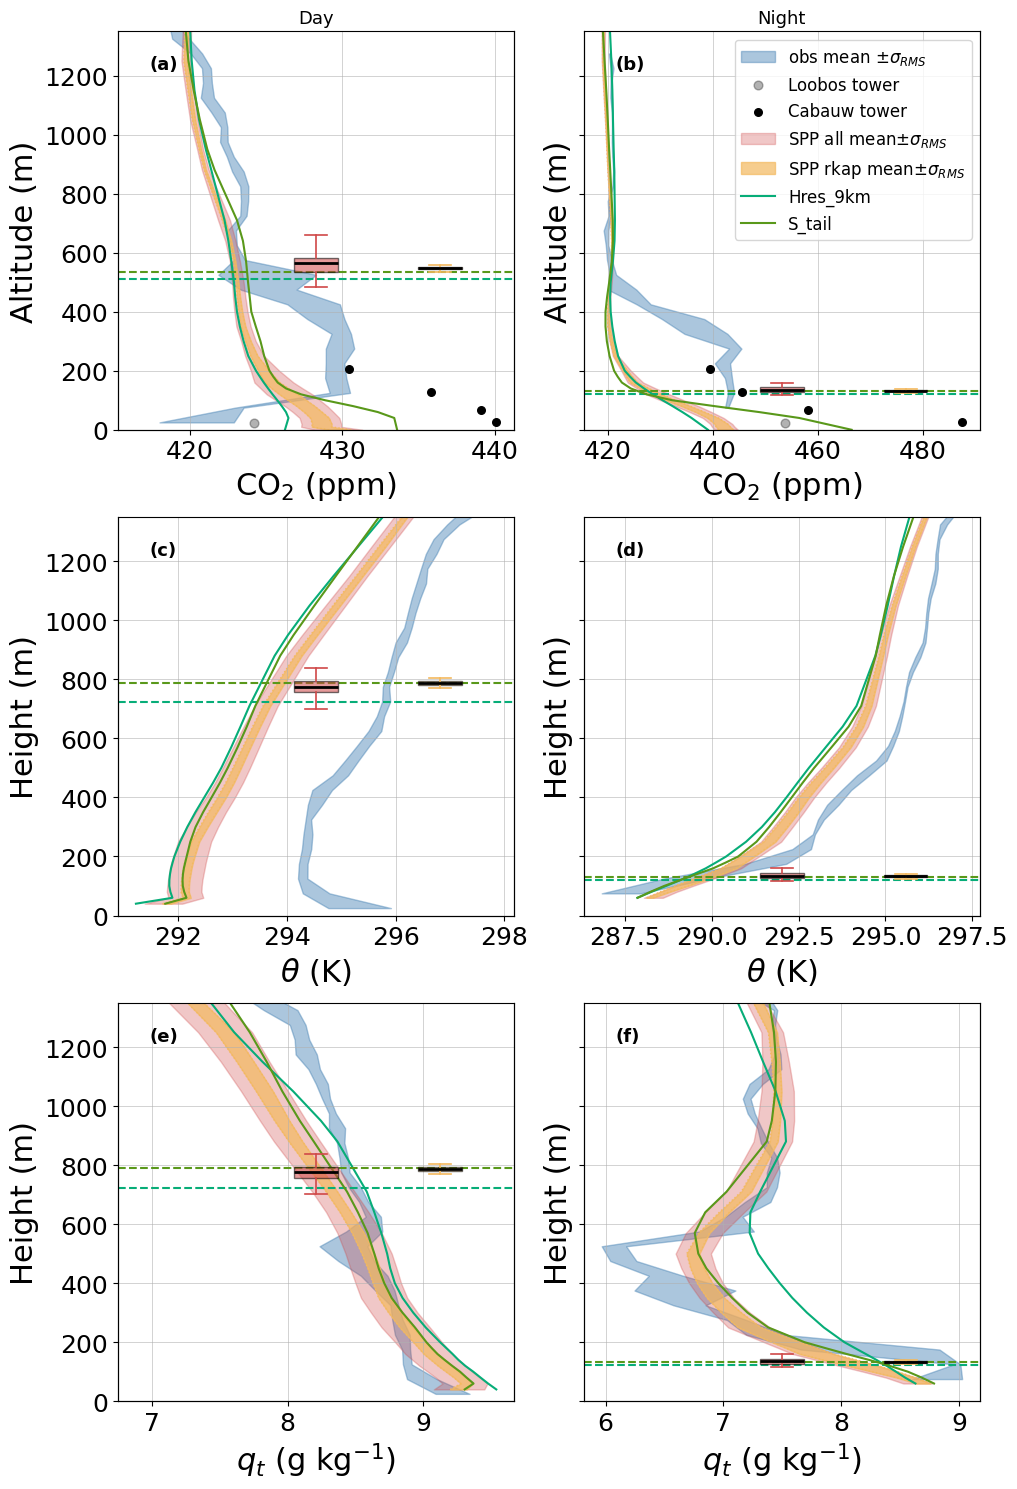


Bin size: 50 m

Aircraft legs   — day: 7, night: 4
Radiosondes     — day: 9, night: 2


In [136]:
## ---- FIGURE 9 ---- ##
# ── Aircraft CO2 + radiosonde θ/qt profiles: binned by altitude ───────────────
# Observations : per-leg/launch, bin by altitude → mean & σ per bin → average
# Model (det.) : 9km_49r2b averaged across legs/radiosonde times
# Model (SPP)  : per-leg/time mean ± σ across members → average
# BLH          : det. axhline + SPP boxplot (twiny)

SPP_EXPS  = ['SPP_all_30', 'SPP_rkap_30']
DET_EXP   = ['9km_49r2b','short_tail_ABL']
site_key  = 'loobos'

# Define bins
bin_size = 50  # m
z_common = np.arange(0, 2101, bin_size)
centers  = (z_common[:-1] + z_common[1:]) / 2

legs_by_col  = [day_legs,        night_legs]
radio_by_col = [day_radio_times, night_radio_times]

_rv_obs = {'th': 'theta', 'qt': 'q'}
_rv_ifs = {'th': 'th',    'qt': 'q'}
_rfac   = {'th': 1,       'qt': 1000}
_rxlab  = {'th': r'$\theta$ (K)', 'qt': r'$q_t$ (g kg$^{-1}$)'}
MAX_H_radio = 1450

# ── Helper: BLH boxplots on a twiny() secondary x-axis ───────────────────────
def _blh_boxplot(ax, blh_box_data, blh_box_colors):
    n = len(blh_box_data)
    if n == 0:
        return
    ax2 = ax.twiny()
    bp  = ax2.boxplot(
        blh_box_data, positions=np.arange(n), widths=0.35, vert=True,
        patch_artist=True, whis=(0, 100), showfliers=False,
        medianprops=dict(color='black', lw=2),
        whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2), zorder=3,
    )
    for patch, col in zip(bp['boxes'], blh_box_colors):
        patch.set_facecolor(col); patch.set_alpha(0.55)
    for artist, col in zip(bp['whiskers'], [c for c in blh_box_colors for _ in range(2)]):
        artist.set_color(col)
    for artist, col in zip(bp['caps'], [c for c in blh_box_colors for _ in range(2)]):
        artist.set_color(col)
    ax2.set_xlim(-1.6, n - 0.4)
    ax2.tick_params(top=False, labeltop=False)
    ax2.spines['top'].set_visible(False)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig_pub2, axes_pub2 = plt.subplots(3, 2, figsize=(10, 15), sharey=True)

# ─────────────────────────────────────────────────────────────────────────────
# ROW 0 : CO2 profiles
# ─────────────────────────────────────────────────────────────────────────────
for icol in range(2):
    ax       = axes_pub2[0, icol]
    legs_sub = legs_by_col[icol]

    # ── Observations: per-leg bin by altitude → mean & σ^2 → average ───────────
    obs_leg_means = np.full([len(centers), len(legs_sub)], np.nan)
    obs_leg_vars  = np.full([len(centers), len(legs_sub)], np.nan)
    for leg_idx, leg in enumerate(legs_sub):
        sel   = ds_loobos['Aircraft_co2_mol'].sel(date=slice(legs[leg][0], legs[leg][1]))
        alt_v = np.asarray(sel['Alt'].values,      dtype=float)
        co2_v = np.asarray(sel['CO2_7815'].values, dtype=float)
        ok    = np.isfinite(alt_v) & np.isfinite(co2_v)
        alt_v, co2_v = alt_v[ok], co2_v[ok]
        bin_idx = np.digitize(alt_v, z_common) - 1
        for ib in range(len(centers)):
            vals = co2_v[bin_idx == ib]
            if len(vals) >= 2:
                obs_leg_means[ib, leg_idx] = np.mean(vals)
                obs_leg_vars[ib, leg_idx]  = np.var(vals)
            elif len(vals) == 1:
                obs_leg_means[ib, leg_idx] = vals[0]

    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        obs_mean = np.nanmean(obs_leg_means, axis=1)
        obs_std  = np.sqrt(np.nanmean(obs_leg_vars,  axis=1))

    valid = np.isfinite(obs_mean)
    ax.fill_betweenx(centers[valid],
                     obs_mean[valid] - obs_std[valid],
                     obs_mean[valid] + obs_std[valid],
                     color='steelblue', alpha=0.45, label=rf'obs mean $\pm \sigma_{{RMS}}$')

    # Tower obs
    tower_mean = np.full([len(legs_sub),5], np.nan)
    for leg_idx, leg in enumerate(legs_sub):
        tower_mean[leg_idx,0] = ds_loobos['Air_Quality']['co2_mixing_ratio'].sel(time=midd_times[leg], method='nearest')
        tower_mean[leg_idx,1] = ds_cabauw['Cabauw_CO2_May2022']['co2_27m'].sel(time=midd_times[leg], method='nearest')
        tower_mean[leg_idx,2] = ds_cabauw['Cabauw_CO2_May2022']['co2_67m'].sel(time=midd_times[leg], method='nearest')
        tower_mean[leg_idx,3] = ds_cabauw['Cabauw_CO2_May2022']['co2_127m'].sel(time=midd_times[leg], method='nearest')
        tower_mean[leg_idx,4] = ds_cabauw['Cabauw_CO2_May2022']['co2_207m'].sel(time=midd_times[leg], method='nearest')

    ax.scatter(np.mean(tower_mean[:,0]), loobos_height, c='k', alpha=0.3, s=40, label='Loobos tower', zorder=3)
    ax.scatter(np.mean(tower_mean[:,1]), 27, c='k', s=30, zorder=3)
    ax.scatter(np.mean(tower_mean[:,2]), 67, c='k', s=30, zorder=3)
    ax.scatter(np.mean(tower_mean[:,3]), 127, c='k', s=30, zorder=3)
    ax.scatter(np.mean(tower_mean[:,4]), 207, c='k', s=30, label='Cabauw tower', zorder=3)

    # ── SPP: per-leg mean ± σ across members → average across legs ────────────
    blh_box_data   = []
    blh_box_colors = []
    for spp_exp, _, spp_label, spp_color in nemo_exp_names:
        if spp_exp not in SPP_EXPS:
            continue
        _leg_profs = []
        for leg in legs_sub:
            try:
                _dse = (IFS_nemo[site_key]['z'][spp_exp]
                        .sel(time=midd_times[leg], method='nearest')
                        .sel(height=slice(0, 2200)))
                _leg_profs.append(_dse['co2_ppm'])
            except Exception:
                pass
        if _leg_profs:
            _stacked   = xr.concat(_leg_profs, dim='leg')
            if 'number' in _stacked.dims:
                _leg_means = _stacked.mean('number', skipna=True)
                _leg_vars  = _stacked.var('number',  skipna=True)
                spp_mean   = _leg_means.mean('leg', skipna=True)
                spp_std    = np.sqrt(_leg_vars.mean('leg',  skipna=True))
                alpha = 0.3 if 'SPP_all' in spp_exp else 0.7
                if alpha == 0.7:
                    ax.plot((spp_mean - spp_std).values, spp_mean['height'].values,
                            color=spp_color, lw=1.0, ls=':')
                    ax.plot((spp_mean + spp_std).values, spp_mean['height'].values,
                            color=spp_color, lw=1.0, ls=':')
                ax.fill_betweenx(spp_mean['height'].values,
                                 (spp_mean - spp_std).values,
                                 (spp_mean + spp_std).values,
                                 color=spp_color, alpha=alpha, label=rf'{spp_label} mean$\pm \sigma_{{RMS}}$')
        # BLH at leg mid-times for boxplot
        try:
            blh_all = IFS_nemo[site_key]['srf'][spp_exp]['blh']
            _blh_leg_vals = []
            for leg in legs_sub:
                try:
                    _blh_leg_vals.append(blh_all.sel(time=midd_times[leg], method='nearest').values)
                except Exception:
                    pass
            blh_per_member = (np.nanmean(np.stack(_blh_leg_vals, axis=0), axis=0)
                              if _blh_leg_vals else
                              np.full(blh_all.sizes.get('number', 1), np.nan))
            blh_box_data.append(blh_per_member)
            blh_box_colors.append(spp_color)
        except Exception:
            pass

    # ── IFS 9km_49r2b deterministic profile + BLH axhline ─────────────────────
    for exp, _, label, color in exp_names:
        if exp not in DET_EXP:
            continue
        _lco2 = []
        for leg in legs_sub:
            try:
                _dse = (IFS[site_key]['z'][exp]
                        .sel(time=midd_times[leg], method='nearest')
                        .sel(height=slice(0, 2200)))
                _lco2.append(_dse['co2'])
            except Exception:
                pass
        if _lco2:
            _mifs = xr.concat(_lco2, dim='leg').mean('leg', skipna=True)
            ax.plot(_mifs.values, _mifs['height'].values, color=color, lw=1.5, label=label)
            _blh_vals = []
            for leg in legs_sub:
                try:
                    _srf = IFS[site_key]['srf'][exp].sel(time=midd_times[leg], method='nearest')
                    _blh_vals.append(float(_srf['blh'].values))
                except Exception:
                    pass
            if _blh_vals:
                ax.axhline(np.nanmean(_blh_vals), color=color, lw=1.5, ls='--')

    _blh_boxplot(ax, blh_box_data, blh_box_colors)
    ax.set_ylim(0, 1450)
    ax.set_xlabel('CO$_2$ (ppm)')
    ax.set_ylabel('Altitude (m)')
    ax.set_title(f'{"Day" if icol == 0 else "Night"}', fontsize=13)
    # ax.legend(fontsize=9)
    ax.grid(True, lw=0.5, alpha=0.8)
    ax.set_xlim(4160, 490)

# ─────────────────────────────────────────────────────────────────────────────
# ROWS 1–2 : θ (row 1) and qt (row 2) — radiosonde profiles
# ─────────────────────────────────────────────────────────────────────────────
for ivar, var in enumerate(['th', 'qt']):
    var_obs = _rv_obs[var]
    var_ifs = _rv_ifs[var]
    fac     = _rfac[var]

    for icol in range(2):
        ax   = axes_pub2[ivar + 1, icol]
        tset = radio_by_col[icol]

        blh_box_data   = []
        blh_box_colors = []

        if tset:
            # ── Obs: per-launch bin by altitude → mean & σ → average ─────────
            obs_launch_means = np.full([len(centers), len(tset)], np.nan)
            obs_launch_vars  = np.full([len(centers), len(tset)], np.nan)
            for t_idx, t in enumerate(tset):
                _rt    = loobos_radio.sel(time=t).sel(Height=slice(0, MAX_H_radio))
                _h_v   = np.asarray(_rt['Height'].values, dtype=float)
                _var_v = np.asarray(fac * _rt[var_obs].values, dtype=float)
                _ok    = np.isfinite(_h_v) & np.isfinite(_var_v)
                _h_ok, _var_ok = _h_v[_ok], _var_v[_ok]
                _bin_idx = np.digitize(_h_ok, z_common) - 1
                for ib in range(len(centers)):
                    vals = _var_ok[_bin_idx == ib]
                    if len(vals) >= 2:
                        obs_launch_means[ib, t_idx] = np.mean(vals)
                        obs_launch_vars[ib, t_idx]  = np.var(vals)
                    elif len(vals) == 1:
                        obs_launch_means[ib, t_idx] = vals[0]

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                obs_mean = np.nanmean(obs_launch_means, axis=1)
                obs_std  = np.sqrt(np.nanmean(obs_launch_vars,  axis=1))

            valid = np.isfinite(obs_mean)
            ax.fill_betweenx(centers[valid],
                             obs_mean[valid] - obs_std[valid],
                             obs_mean[valid] + obs_std[valid],
                             color='steelblue', alpha=0.45,
                             label=rf'Radiosonde mean $\pm \sigma_{{RMS}}$ (n={len(tset)})')

            # ── SPP: per-time mean ± σ across members → average across times ──
            for spp_exp, _, spp_label, spp_color in nemo_exp_names:
                if spp_exp not in SPP_EXPS:
                    continue
                _lmod_spp = []
                for t in tset:
                    _rt  = loobos_radio.sel(time=t).sel(Height=slice(0, MAX_H_radio))
                    _ov  = _rt[var_obs].values
                    _hv  = _rt['Height'].values
                    _vld = np.isfinite(fac * _ov)
                    if _vld.sum() < 2:
                        continue
                    _zmin = float(_hv[_vld].min())
                    _zmax = float(_hv[_vld].max())
                    try:
                        _mt = (IFS_nemo[site_key]['z'][spp_exp]
                               .sel(time=t, method='nearest')
                               .sel(height=slice(0, MAX_H_radio)))
                        _lmod_spp.append(_mt[var_ifs].where(
                            (_mt['height'] >= _zmin) & (_mt['height'] <= _zmax)
                        ))
                    except Exception:
                        pass
                if _lmod_spp:
                    _spp_stack = xr.concat(_lmod_spp, dim='time')
                    if 'number' in _spp_stack.dims:
                        _t_means  = (fac * _spp_stack).mean('number', skipna=True)
                        _t_vars   = (fac * _spp_stack).var('number',  skipna=True)
                        _spp_mean = _t_means.mean('time', skipna=True)
                        _spp_std  = np.sqrt(_t_vars.mean('time',  skipna=True))
                        alpha = 0.3 if 'SPP_all' in spp_exp else 0.7
                        if alpha == 0.7:
                            ax.plot((_spp_mean - _spp_std).values, _spp_mean['height'].values,
                                    color=spp_color, lw=1.0, ls=':')
                            ax.plot((_spp_mean + _spp_std).values, _spp_mean['height'].values,
                                    color=spp_color, lw=1.0, ls=':')
                        ax.fill_betweenx(_spp_mean['height'].values,
                                         (_spp_mean - _spp_std).values,
                                         (_spp_mean + _spp_std).values,
                                         color=spp_color, alpha=alpha,
                                         label=rf'{spp_label} mean $\pm \sigma_{{RMS}}$')
                # BLH at radiosonde times for boxplot
                try:
                    blh_all = IFS_nemo[site_key]['srf'][spp_exp]['blh']
                    _blh_radio_vals = []
                    for t in tset:
                        try:
                            _blh_radio_vals.append(blh_all.sel(time=t, method='nearest').values)
                        except Exception:
                            pass
                    blh_per_member = (np.nanmean(np.stack(_blh_radio_vals, axis=0), axis=0)
                                      if _blh_radio_vals else
                                      np.full(blh_all.sizes.get('number', 1), np.nan))
                    blh_box_data.append(blh_per_member)
                    blh_box_colors.append(spp_color)
                except Exception:
                    pass

            # ── IFS 9km_49r2b deterministic profile + BLH axhline ─────────────
            for exp, _, label, color in exp_names:
                if exp not in DET_EXP:
                    continue
                _lmod = []
                for t in tset:
                    _rt  = loobos_radio.sel(time=t).sel(Height=slice(0, MAX_H_radio))
                    _ov  = _rt[var_obs].values
                    _hv  = _rt['Height'].values
                    _vld = np.isfinite(_ov)
                    if _vld.sum() < 2:
                        continue
                    _zmin = float(_hv[_vld].min())
                    _zmax = float(_hv[_vld].max())
                    try:
                        _mt = (IFS[site_key]['z'][exp]
                               .sel(time=t, method='nearest')
                               .sel(height=slice(0, MAX_H_radio)))
                        _lmod.append((_mt[var_ifs]).where(
                            (_mt['height'] >= _zmin) & (_mt['height'] <= _zmax)
                        ))
                    except Exception:
                        pass
                if _lmod:
                    _mm = xr.concat(_lmod, dim='time').mean('time', skipna=True)
                    ax.plot(_mm.values, _mm['height'].values, color=color, lw=1.5, label=label)
                    _blh_ts = []
                    for t in tset:
                        try:
                            _srf = IFS[site_key]['srf'][exp].sel(time=t, method='nearest')
                            _blh_ts.append(float(_srf['blh'].values))
                        except Exception:
                            pass
                    if _blh_ts:
                        ax.axhline(np.nanmean(_blh_ts), color=color, lw=1.5, ls='--')

        _blh_boxplot(ax, blh_box_data, blh_box_colors)
        ax.set_ylim(0, MAX_H_radio-100)
        ax.set_xlabel(_rxlab[var])
        ax.set_ylabel('Height (m)')
        ax.grid(True, lw=0.5, alpha=0.8)

        ax.set_xlim(5.9, 9.6) if var == 'qt' else ax.set_xlim(286, 298)

axes_pub2[0,1].legend(fontsize=12)

# ── Panel letters ──────────────────────────────────────────────────────────────
for irow in range(3):
    for icol in range(2):
        letter = 'abcdef'[irow * 2 + icol]
        axes_pub2[irow, icol].text(
            0.08, 0.94, f'({letter})', transform=axes_pub2[irow, icol].transAxes,
            fontsize=13, fontweight='bold', va='top', ha='left'
        )

plt.tight_layout()
plt.savefig(os.path.join(dir_out, f"SPP_andobs_profiles_{site_key}.png"), dpi=300, bbox_inches='tight')
plt.show()


print(f"\nBin size: {bin_size} m")
print(f"\nAircraft legs   — day: {len(day_legs)}, night: {len(night_legs)}")
print(f"Radiosondes     — day: {len(day_radio_times)}, night: {len(night_radio_times)}")


In [50]:
IFS.keys()

dict_keys(['3d_nl', 'slab_nl', 'cabauw', 'loobos', '3d_hpb', 'slab_hpb', 'HPB_tower'])

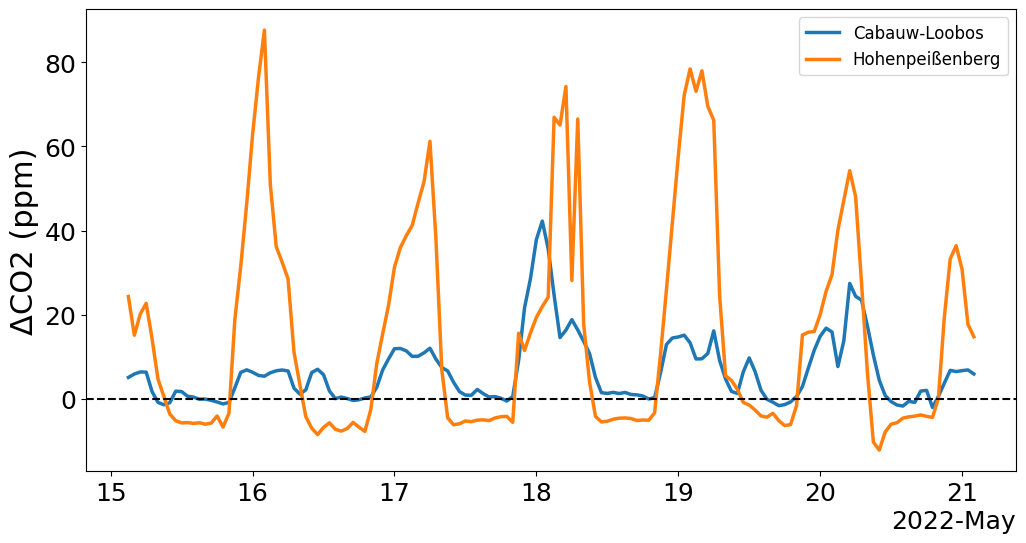

In [58]:
# Delta co2 ocntration at BL top and surface 
labels = ['Cabauw-Loobos','Hohenpeißenberg']
plt.figure(figsize=(12,6))
# for station in ['loobos','cabauw','HPB_tower']:
for ie,station in enumerate(['slab_nl','slab_hpb']):
    blh = IFS[station]['srf']['ctrl_49r2b']['blh']
    near_surface_co2 = IFS[station]['z']['ctrl_49r2b']['co2'].sel(height=10,method='nearest')
    near_BLH_co2 = IFS[station]['z']['ctrl_49r2b']['co2'].sel(height=blh,method='nearest')
    (near_surface_co2 - near_BLH_co2).plot(lw=2.5,label=f'{labels[ie]}')
plt.axhline(0,color='k',ls='--')
# plt.title('ΔCO2 (surface - BLH) for ctrl_49r2b')
plt.ylabel('ΔCO2 (ppm)')
plt.xlabel('')
plt.legend()